In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

%matplotlib inline

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = "/kaggle/input/datasets/mdfaysalhossan/5111-image-dataset-sunflower/Sunflower Compressed"

image_size = (224, 224)
batch_size = 32
epochs = 1
dropout_rate = 0.5

weight_decay = 1e-4

if not os.path.exists(DATA_DIR):
    raise ValueError("Dataset path incorrect!")

print("📁 Dataset path OK")
print(f"🖼️ Image size: {image_size}")
print(f"📦 Batch size: {batch_size}")
print(f"🔁 Epochs: {epochs}")
print(f"⚖️ Weight Decay (L2): {weight_decay}")

Using device: cuda
📁 Dataset path OK
🖼️ Image size: (224, 224)
📦 Batch size: 32
🔁 Epochs: 1
⚖️ Weight Decay (L2): 0.0001


In [2]:
class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
num_classes = len(class_names)
print(f"Classes: {class_names}, Number of classes: {num_classes}")

paths, labels = [], []
for class_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            paths.append(os.path.join(class_dir, fname))
            labels.append(class_idx)

if len(paths) == 0:
    raise ValueError("No images found! Verify folder structure and file extensions.")

print(f"Total images: {len(paths)}")

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.3, stratify=labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

Classes: ['EarlyBloom', 'Healthy', 'MatureBud', 'Wilted', 'YoungBud'], Number of classes: 5
Total images: 5111
Train: 3577, Val: 767, Test: 767


In [3]:
from PIL import Image
import cv2
import numpy as np
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

class SunflowerDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

class AdvancedPreprocessing:
    """
    CLAHE (LAB) → Gamma Correction → Denoising
    Input: PIL.Image (RGB)
    Output: PIL.Image (RGB)
    """
    def __init__(self, gamma=1.2, clipLimit=2.0, tileGridSize=(8,8)):
        self.gamma = float(gamma)
        self.clipLimit = float(clipLimit)
        self.tileGridSize = (int(tileGridSize[0]), int(tileGridSize[1]))

    def __call__(self, img):
        arr = np.array(img)

        lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=self.clipLimit,
            tileGridSize=self.tileGridSize
        )
        l2 = clahe.apply(l)

        lab2 = cv2.merge((l2, a, b))
        rgb = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)

        invGamma = 1.0 / (self.gamma + 1e-12)
        table = np.array([
            ((i / 255.0) ** invGamma) * 255
            for i in np.arange(256)
        ]).astype("uint8")

        gamma_corrected = cv2.LUT(rgb, table)

        denoised = cv2.fastNlMeansDenoisingColored(
            gamma_corrected,
            None,
            h=10,
            hColor=10,
            templateWindowSize=7,
            searchWindowSize=21
        )

        return Image.fromarray(denoised)

transform = transforms.Compose([
    transforms.Resize(image_size),
    AdvancedPreprocessing(gamma=1.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_ds = SunflowerDataset(train_paths, train_labels, transform=transform)
val_ds = SunflowerDataset(val_paths, val_labels, transform=transform)
test_ds = SunflowerDataset(test_paths, test_labels, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

for images, labels in train_loader:
    print(f"Sample batch shape: Images {images.shape}, Labels {labels.shape}")
    break

Sample batch shape: Images torch.Size([32, 3, 224, 224]), Labels torch.Size([32])


In [4]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.ReLU(),
            nn.Linear(dim, 2)
        )

    def forward(self, d_feat, v_feat):
        combined = torch.cat([d_feat, v_feat], dim=1)
        weights = torch.softmax(self.fc(combined), dim=1)

        w1 = weights[:, 0:1]
        w2 = weights[:, 1:2]

        fused = w1 * d_feat + w2 * v_feat
        return fused

class DenseNet201_FusionViT_Advanced(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.densenet = timm.create_model(
            'densenet201',
            pretrained=True,
            features_only=True
        )

        densenet_channels = self.densenet.feature_info[-1]['num_chs']

        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True,
            num_classes=0
        )

        for param in self.densenet.parameters():
            param.requires_grad = False

        for name, param in self.vit.named_parameters():
            if "blocks.11" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.proj_d = nn.Linear(densenet_channels, 512)
        self.proj_v = nn.Linear(self.vit.num_features, 512)

        self.fusion = AttentionFusion(512)

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        d_feat_map = self.densenet(x)[-1]
        d_feat = self.pool(d_feat_map).view(x.size(0), -1)

        v_feat = self.vit(x)

        d_feat = self.proj_d(d_feat)
        v_feat = self.proj_v(v_feat)

        fused = self.fusion(d_feat, v_feat)

        logits = self.classifier(fused)

        return logits

model = DenseNet201_FusionViT_Advanced(num_classes).to(device)
print(model)

model.safetensors:   0%|          | 0.00/81.1M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

DenseNet201_FusionViT_Advanced(
  (densenet): FeatureListNet(
    (features_conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (features_norm0): BatchNormAct2d(
      64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
    (features_pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (features_denseblock1): DenseBlock(
      (denselayer1): DenseLayer(
        (norm1): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNormAct2d(
          128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv2): Conv2d(128, 32, kernel_size

In [5]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4
Capability: (7, 5)


In [6]:
!nvidia-smi

Sat Sep 12 12:58:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             26W /   70W |     551MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
import torch
import torch.nn as nn
import copy
from tqdm import tqdm
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode

        self.best_score = None
        self.counter = 0
        self.best_weights = None

    def step(self, metric, model):
        if self.best_score is None:
            self.best_score = metric
            self.best_weights = copy.deepcopy(model.state_dict())
            print("🔰 Initial best model saved")
            return False

        if self.mode == 'min':
            improvement = self.best_score - metric > self.min_delta
        else:
            improvement = metric - self.best_score > self.min_delta

        if improvement:
            self.best_score = metric
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
            print("✅ Improvement detected")
        else:
            self.counter += 1
            print(f"⚠️ No improvement ({self.counter}/{self.patience})")

        return self.counter >= self.patience

model = model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=3
)

early_stopper = EarlyStopping(patience=5)

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

def forward_pass(model, images, labels, loss_fn):

    outputs = model(images)

    if not isinstance(outputs, tuple):
        logits = outputs
        loss = loss_fn(logits, labels)
        uncertainty = None

    elif len(outputs) == 2:
        logits, uncertainty = outputs
        loss = loss_fn(logits, labels) + 0.05 * uncertainty.mean()

    elif len(outputs) == 3:
        logits, uncertainty, _ = outputs
        loss = loss_fn(logits, labels) + 0.05 * uncertainty.mean()

    else:
        raise ValueError("Unexpected model output format")

    return logits, loss

for epoch in range(epochs):

    model.train()
    running_loss, correct = 0.0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        logits, loss = forward_pass(model, images, labels, loss_fn)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / len(train_loader.dataset)

    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} Val"):
            images, labels = images.to(device), labels.to(device)

            logits, loss = forward_pass(model, images, labels, loss_fn)

            val_loss += loss.item() * images.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"🔽 LR reduced: {old_lr:.6f} → {new_lr:.6f}")

    if early_stopper.step(val_loss, model):
        print("\n⛔ Early stopping triggered!")
        break

    torch.cuda.empty_cache()

model.load_state_dict(early_stopper.best_weights)
torch.save(model.state_dict(), "best_model.pth")

Epoch 1 Val: 100%|██████████| 24/24 [02:25<00:00,  6.07s/it]



Epoch 1
Train Loss: 0.6663, Acc: 0.8787
Val   Loss: 0.6017, Acc: 0.9035
🔰 Initial best model saved


=== Evaluating on test set ===
Final test loss: 0.5721
Final test accuracy: 0.9166

=== Confusion Matrix ===


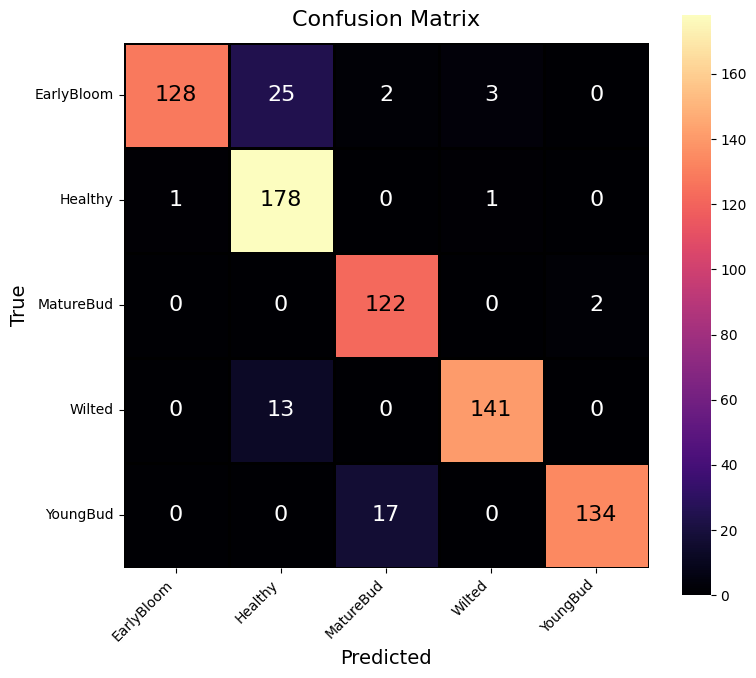


=== Classification Report ===
              precision    recall  f1-score   support

  EarlyBloom       0.99      0.81      0.89       158
     Healthy       0.82      0.99      0.90       180
   MatureBud       0.87      0.98      0.92       124
      Wilted       0.97      0.92      0.94       154
    YoungBud       0.99      0.89      0.93       151

    accuracy                           0.92       767
   macro avg       0.93      0.92      0.92       767
weighted avg       0.93      0.92      0.92       767



In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("=== Evaluating on test set ===")

def get_logits(model, images):
    outputs = model(images)

    if isinstance(outputs, tuple):
        logits = outputs[0]
    else:
        logits = outputs

    return logits

model.eval()
test_loss = 0.0
test_correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        logits = get_logits(model, images)

        loss = loss_fn(logits, labels)

        test_loss += loss.item() * images.size(0)
        test_correct += (logits.argmax(1) == labels).sum().item()

test_loss /= len(test_loader.dataset)
test_acc = test_correct / len(test_loader.dataset)

print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

preds = []
true_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        logits = get_logits(model, images)

        preds.append(logits.cpu().numpy())
        true_list.append(labels.numpy())

y_pred = np.concatenate(preds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate(true_list)

print("\n=== Confusion Matrix ===")

cm = confusion_matrix(y_true, y_pred_classes)

class_names = ['EarlyBloom', 'Healthy', 'MatureBud', 'Wilted', 'YoungBud']

plt.figure(figsize=(8, 7))

ax = sns.heatmap(
    cm,
    cmap='magma',
    xticklabels=class_names,
    yticklabels=class_names,
    square=True,
    cbar=True,
    linewidths=0.8,
    linecolor='black',
    annot=False
)

threshold = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] < threshold else "black"
        ax.text(
            j + 0.5,
            i + 0.5,
            format(cm[i, j], 'd'),
            ha="center",
            va="center",
            fontsize=16,
            color=color
        )

plt.title("Confusion Matrix", fontsize=16, pad=12)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred_classes, target_names=class_names))


=== Training and Validation Loss ===


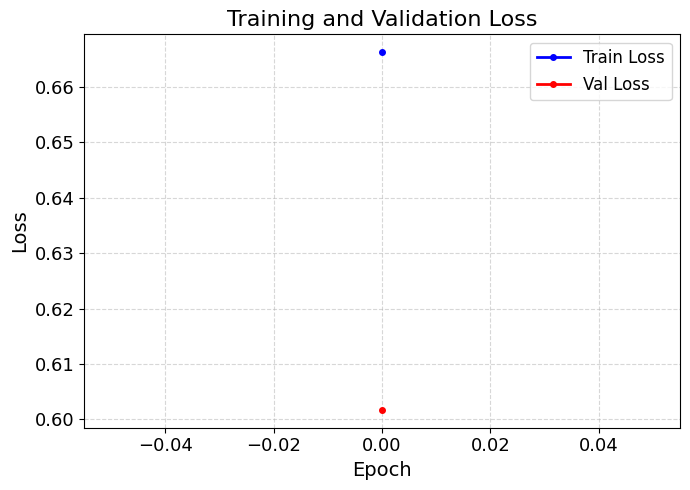

Part 7A Complete

=== Part 7B: Training and Validation Accuracy ===


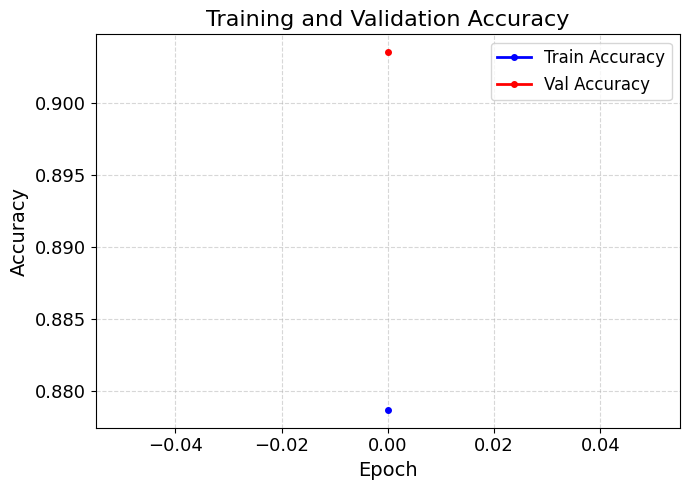

In [11]:
print("\n=== Training and Validation Loss ===")

plt.figure(figsize=(7, 5))

plt.plot(
    history['loss'],
    label='Train Loss',
    color='blue',
    linestyle='-',
    linewidth=2,
    marker='o',
    markersize=4
)
plt.plot(
    history['val_loss'],
    label='Val Loss',
    color='red',
    linestyle='-',
    linewidth=2,
    marker='o',
    markersize=4
)

plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)

plt.legend(frameon=True, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.tight_layout()
plt.show()

print("Part 7A Complete")


# -----------------------------
# Part 7B: Training & Validation Accuracy (Line + Circle Points)
# -----------------------------
print("\n=== Part 7B: Training and Validation Accuracy ===")

plt.figure(figsize=(7, 5))

plt.plot(
    history['accuracy'],
    label='Train Accuracy',
    color='blue',
    linestyle='-',
    linewidth=2,
    marker='o',
    markersize=4
)
plt.plot(
    history['val_accuracy'],
    label='Val Accuracy',
    color='red',
    linestyle='-',
    linewidth=2,
    marker='o',
    markersize=4
)

plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

plt.legend(frameon=True, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.tight_layout()
plt.show()


=== ROC Curves (AUC) ===


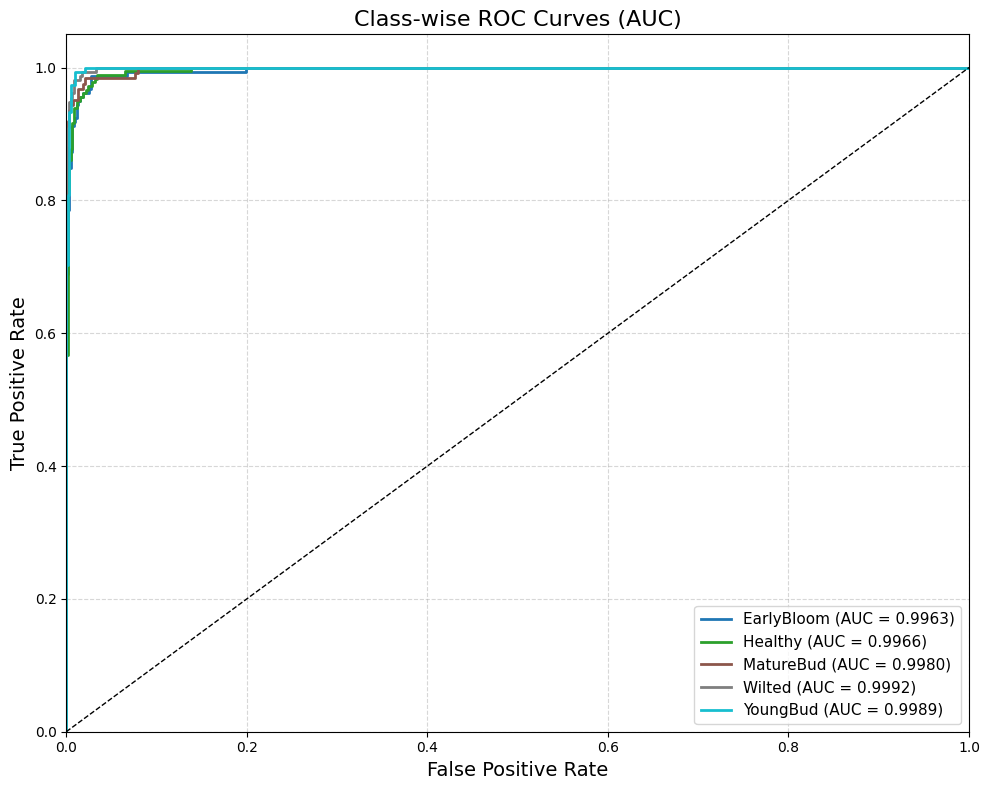

In [12]:
print("\n=== ROC Curves (AUC) ===")

import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

if len(class_names) != num_classes:
    class_names = [f"Class {i}" for i in range(num_classes)]

y_pred_prob = y_pred.copy()

if y_pred_prob.max() > 1 or y_pred_prob.min() < 0:
    exp = np.exp(y_pred_prob - np.max(y_pred_prob, axis=1, keepdims=True))
    y_pred_prob = exp / np.sum(exp, axis=1, keepdims=True)

y_true_bin = label_binarize(y_true, classes=range(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

for i in range(num_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.4f})"
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)

plt.title('Class-wise ROC Curves (AUC)', fontsize=16)

plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
!pip install thop

In [14]:
import torch
import time
import pandas as pd
from thop import profile
import os

model.eval()

dummy_input = torch.randn(1, 3, image_size[0], image_size[1]).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

total_params_m = total_params / 1e6
trainable_params_m = trainable_params / 1e6
non_trainable_params_m = non_trainable_params / 1e6

flops, _ = profile(model, inputs=(dummy_input,), verbose=False)
gflops = flops / 1e9

if device.type == 'cuda':
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize()

    repetitions = 50
    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)

    timings = []

    with torch.no_grad():
        for _ in range(repetitions):
            starter.record()
            _ = model(dummy_input)
            ender.record()

            torch.cuda.synchronize()
            timings.append(starter.elapsed_time(ender))

    avg_inference_time = sum(timings) / len(timings)
    peak_vram_gb = torch.cuda.max_memory_allocated(device) / (1024 ** 3)

else:
    repetitions = 50
    timings = []

    with torch.no_grad():
        for _ in range(repetitions):
            start = time.perf_counter()
            _ = model(dummy_input)
            end = time.perf_counter()
            timings.append((end - start) * 1000)

    avg_inference_time = sum(timings) / len(timings)
    peak_vram_gb = 0.0

model_path = "temp_model.pth"
torch.save(model.state_dict(), model_path)

model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

os.remove(model_path)

if 'training_time_minutes' in globals():
    training_time_min = training_time_minutes
else:
    training_time_min = None

model_name = "DenseNet201 + ViT-B/16"

df = pd.DataFrame([{
    "Model": model_name,
    "Total Params (M)": f"{total_params_m:.2f}",
    "Trainable (M)": f"{trainable_params_m:.2f}",
    "Non-Trainable (M)": f"{non_trainable_params_m:.2f}",
    "GFLOPs": f"{gflops:.2f}",
    "Inference Time (ms)": f"{avg_inference_time:.2f}",
    "Training Time (min)": f"{training_time_min:.2f}" if training_time_min is not None else "N/A",
    "Peak VRAM (GB)": f"{peak_vram_gb:.2f}",
    "Model Size (MB)": f"{model_size_mb:.2f}"
}])

print("\n=== Model Complexity Report ===\n")
print(df.to_string(index=False))


=== Model Complexity Report ===

                 Model Total Params (M) Trainable (M) Non-Trainable (M) GFLOPs Inference Time (ms) Training Time (min) Peak VRAM (GB) Model Size (MB)
DenseNet201 + ViT-B/16           105.93          9.12             96.80  21.14               39.39                 N/A           0.95          405.92


In [15]:
import torch
import torch.nn as nn
import copy
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

cv_paths = np.array(train_paths + val_paths)
cv_labels = np.array(train_labels + val_labels)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(cv_paths, cv_labels), 1):

    print("\n" + "=" * 70)
    print(f"Fold {fold}/5")
    print("=" * 70)

    fold_train_paths = cv_paths[train_idx].tolist()
    fold_train_labels = cv_labels[train_idx].tolist()

    fold_val_paths = cv_paths[val_idx].tolist()
    fold_val_labels = cv_labels[val_idx].tolist()

    fold_train_ds = SunflowerDataset(
        fold_train_paths,
        fold_train_labels,
        transform=transform
    )

    fold_val_ds = SunflowerDataset(
        fold_val_paths,
        fold_val_labels,
        transform=transform
    )

    fold_train_loader = DataLoader(
        fold_train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    fold_val_loader = DataLoader(
        fold_val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    fold_model = DenseNet201_FusionViT_Advanced(num_classes).to(device)

    optimizer = torch.optim.AdamW(
        fold_model.parameters(),
        lr=3e-4,
        weight_decay=1e-4
    )

    loss_fn_cv = nn.CrossEntropyLoss(label_smoothing=0.1)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.3,
        patience=3
    )

    early_stopper = EarlyStopping(
        patience=5,
        min_delta=1e-4,
        mode='min'
    )

    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_epoch = 0

    for epoch in range(epochs):

        fold_model.train()

        running_loss = 0.0
        correct = 0

        for images, labels in tqdm(
            fold_train_loader,
            desc=f"Fold {fold} Epoch {epoch+1} Train"
        ):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = fold_model(images)
            loss = loss_fn_cv(logits, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(1) == labels).sum().item()

        train_loss = running_loss / len(fold_train_loader.dataset)
        train_acc = correct / len(fold_train_loader.dataset)

        fold_model.eval()

        val_running_loss = 0.0
        val_correct = 0

        with torch.no_grad():

            for images, labels in tqdm(
                fold_val_loader,
                desc=f"Fold {fold} Epoch {epoch+1} Val"
            ):

                images = images.to(device)
                labels = labels.to(device)

                logits = fold_model(images)
                loss = loss_fn_cv(logits, labels)

                val_running_loss += loss.item() * images.size(0)
                val_correct += (
                    logits.argmax(1) == labels
                ).sum().item()

        val_loss = val_running_loss / len(fold_val_loader.dataset)
        val_acc = val_correct / len(fold_val_loader.dataset)

        print(
            f"Fold {fold} | Epoch {epoch+1} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1

        old_lr = optimizer.param_groups[0]['lr']

        scheduler.step(val_loss)

        new_lr = optimizer.param_groups[0]['lr']

        if new_lr != old_lr:
            print(
                f"Learning rate reduced: "
                f"{old_lr:.6f} -> {new_lr:.6f}"
            )

        if early_stopper.step(val_loss, fold_model):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    fold_model.load_state_dict(
        early_stopper.best_weights
    )

    fold_results.append({
        "Fold": fold,
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val_loss,
        "Best Val Accuracy": best_val_acc
    })

    print(
        f"\nFold {fold} completed | "
        f"Best Epoch: {best_epoch} | "
        f"Best Val Loss: {best_val_loss:.4f} | "
        f"Best Val Accuracy: {best_val_acc:.4f}"
    )

    del fold_model
    del optimizer
    del scheduler
    del early_stopper

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

cv_results = pd.DataFrame(fold_results)

print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

print(cv_results.to_string(index=False))

mean_acc = cv_results["Best Val Accuracy"].mean()
std_acc = cv_results["Best Val Accuracy"].std()

mean_loss = cv_results["Best Val Loss"].mean()
std_loss = cv_results["Best Val Loss"].std()

print("\nMean Validation Accuracy: {:.4f}".format(mean_acc))
print("Std Validation Accuracy: {:.4f}".format(std_acc))

print("\nMean Validation Loss: {:.4f}".format(mean_loss))
print("Std Validation Loss: {:.4f}".format(std_loss))

print("\n5-Fold Cross-Validation Complete")


Fold 1/5


Fold 1 Epoch 1 Val: 100%|██████████| 28/28 [02:40<00:00,  5.75s/it]


Fold 1 | Epoch 1 | Train Loss: 0.6671 | Train Acc: 0.8777 | Val Loss: 0.5753 | Val Acc: 0.9264
🔰 Initial best model saved

Fold 1 completed | Best Epoch: 1 | Best Val Loss: 0.5753 | Best Val Accuracy: 0.9264

Fold 2/5


Fold 2 Epoch 1 Val: 100%|██████████| 28/28 [02:41<00:00,  5.77s/it]


Fold 2 | Epoch 1 | Train Loss: 0.6771 | Train Acc: 0.8717 | Val Loss: 0.5950 | Val Acc: 0.9033
🔰 Initial best model saved

Fold 2 completed | Best Epoch: 1 | Best Val Loss: 0.5950 | Best Val Accuracy: 0.9033

Fold 3/5


...

Fold 3 | Epoch 1 | Train Loss: 0.6440 | Train Acc: 0.8924 | Val Loss: 0.7874 | Val Acc: 0.7975
🔰 Initial best model saved

Fold 3 completed | Best Epoch: 1 | Best Val Loss: 0.7874 | Best Val Accuracy: 0.7975

Fold 4/5


Fold 4 Epoch 1 Val: 100%|██████████| 28/28 [02:42<00:00,  5.79s/it]


Fold 4 | Epoch 1 | Train Loss: 0.6644 | Train Acc: 0.8814 | Val Loss: 0.6194 | Val Acc: 0.9137
🔰 Initial best model saved

Fold 4 completed | Best Epoch: 1 | Best Val Loss: 0.6194 | Best Val Accuracy: 0.9137

Fold 5/5


Fold 5 Epoch 1 Val: 100%|██████████| 28/28 [02:43<00:00,  5.83s/it]

Fold 5 | Epoch 1 | Train Loss: 0.6700 | Train Acc: 0.8740 | Val Loss: 0.6591 | Val Acc: 0.8698
🔰 Initial best model saved

Fold 5 completed | Best Epoch: 1 | Best Val Loss: 0.6591 | Best Val Accuracy: 0.8698

5-FOLD CROSS-VALIDATION RESULTS
 Fold  Best Epoch  Best Val Loss  Best Val Accuracy
    1           1       0.575294           0.926352
    2           1       0.595014           0.903337
    3           1       0.787426           0.797468
    4           1       0.619393           0.913694
    5           1       0.659097           0.869816

Mean Validation Accuracy: 0.8821
Std Validation Accuracy: 0.0518

Mean Validation Loss: 0.6472
Std Validation Loss: 0.0844

5-Fold Cross-Validation Complete


In [16]:
import numpy as np
import torch
from scipy.stats import ttest_1samp

print("=== Statistical Significance Test (Proposed Model Only) ===")

def get_correctness(model, loader):
    model.eval()
    correct_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = outputs.argmax(1)
            correct = (preds == labels).float()

            correct_list.extend(correct.cpu().numpy())

    return np.array(correct_list)

correctness = get_correctness(model, test_loader)

baseline = 1.0 / num_classes

print(f"Model Accuracy: {correctness.mean():.4f}")
print(f"Baseline (Random Guess): {baseline:.4f}")

t_stat, p_value = ttest_1samp(correctness, baseline)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("Model performance is statistically better than random baseline")
else:
    print("Not statistically significant")

def cohens_d(sample, mu):
    return (np.mean(sample) - mu) / np.std(sample)

d = cohens_d(correctness, baseline)

print(f"Cohen's d: {d:.4f}")

print("=== Test Complete ===")

=== Statistical Significance Test (Proposed Model Only) ===
Model Accuracy: 0.9166
Baseline (Random Guess): 0.2000
T-statistic: 71.7123
P-value: 0.000000
Model performance is statistically better than random baseline
Cohen's d: 2.5911
=== Test Complete ===


In [17]:
import numpy as np
import torch
from scipy.stats import t

print("=== Confidence Interval (95%) ===")

def get_correctness(model, loader):
    model.eval()
    correct_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = outputs.argmax(1)
            correct = (preds == labels).float()

            correct_list.extend(correct.cpu().numpy())

    return np.array(correct_list)

correctness = get_correctness(model, test_loader)

n = len(correctness)
mean_acc = np.mean(correctness)
std_err = np.std(correctness, ddof=1) / np.sqrt(n)

confidence = 0.95
t_value = t.ppf((1 + confidence) / 2, df=n-1)

margin = t_value * std_err

lower = mean_acc - margin
upper = mean_acc + margin

print(f"Accuracy: {mean_acc:.4f}")
print(f"95% CI: [{lower:.4f}, {upper:.4f}]")

=== Confidence Interval (95%) ===
Accuracy: 0.9166
95% CI: [0.8969, 0.9362]
=== Done ===


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]


=== LIME METRICS ===
Mean IoU: 0.2376

Paired t-test Results
t-statistic: 6.1012
p-value: 0.0036513031193796536


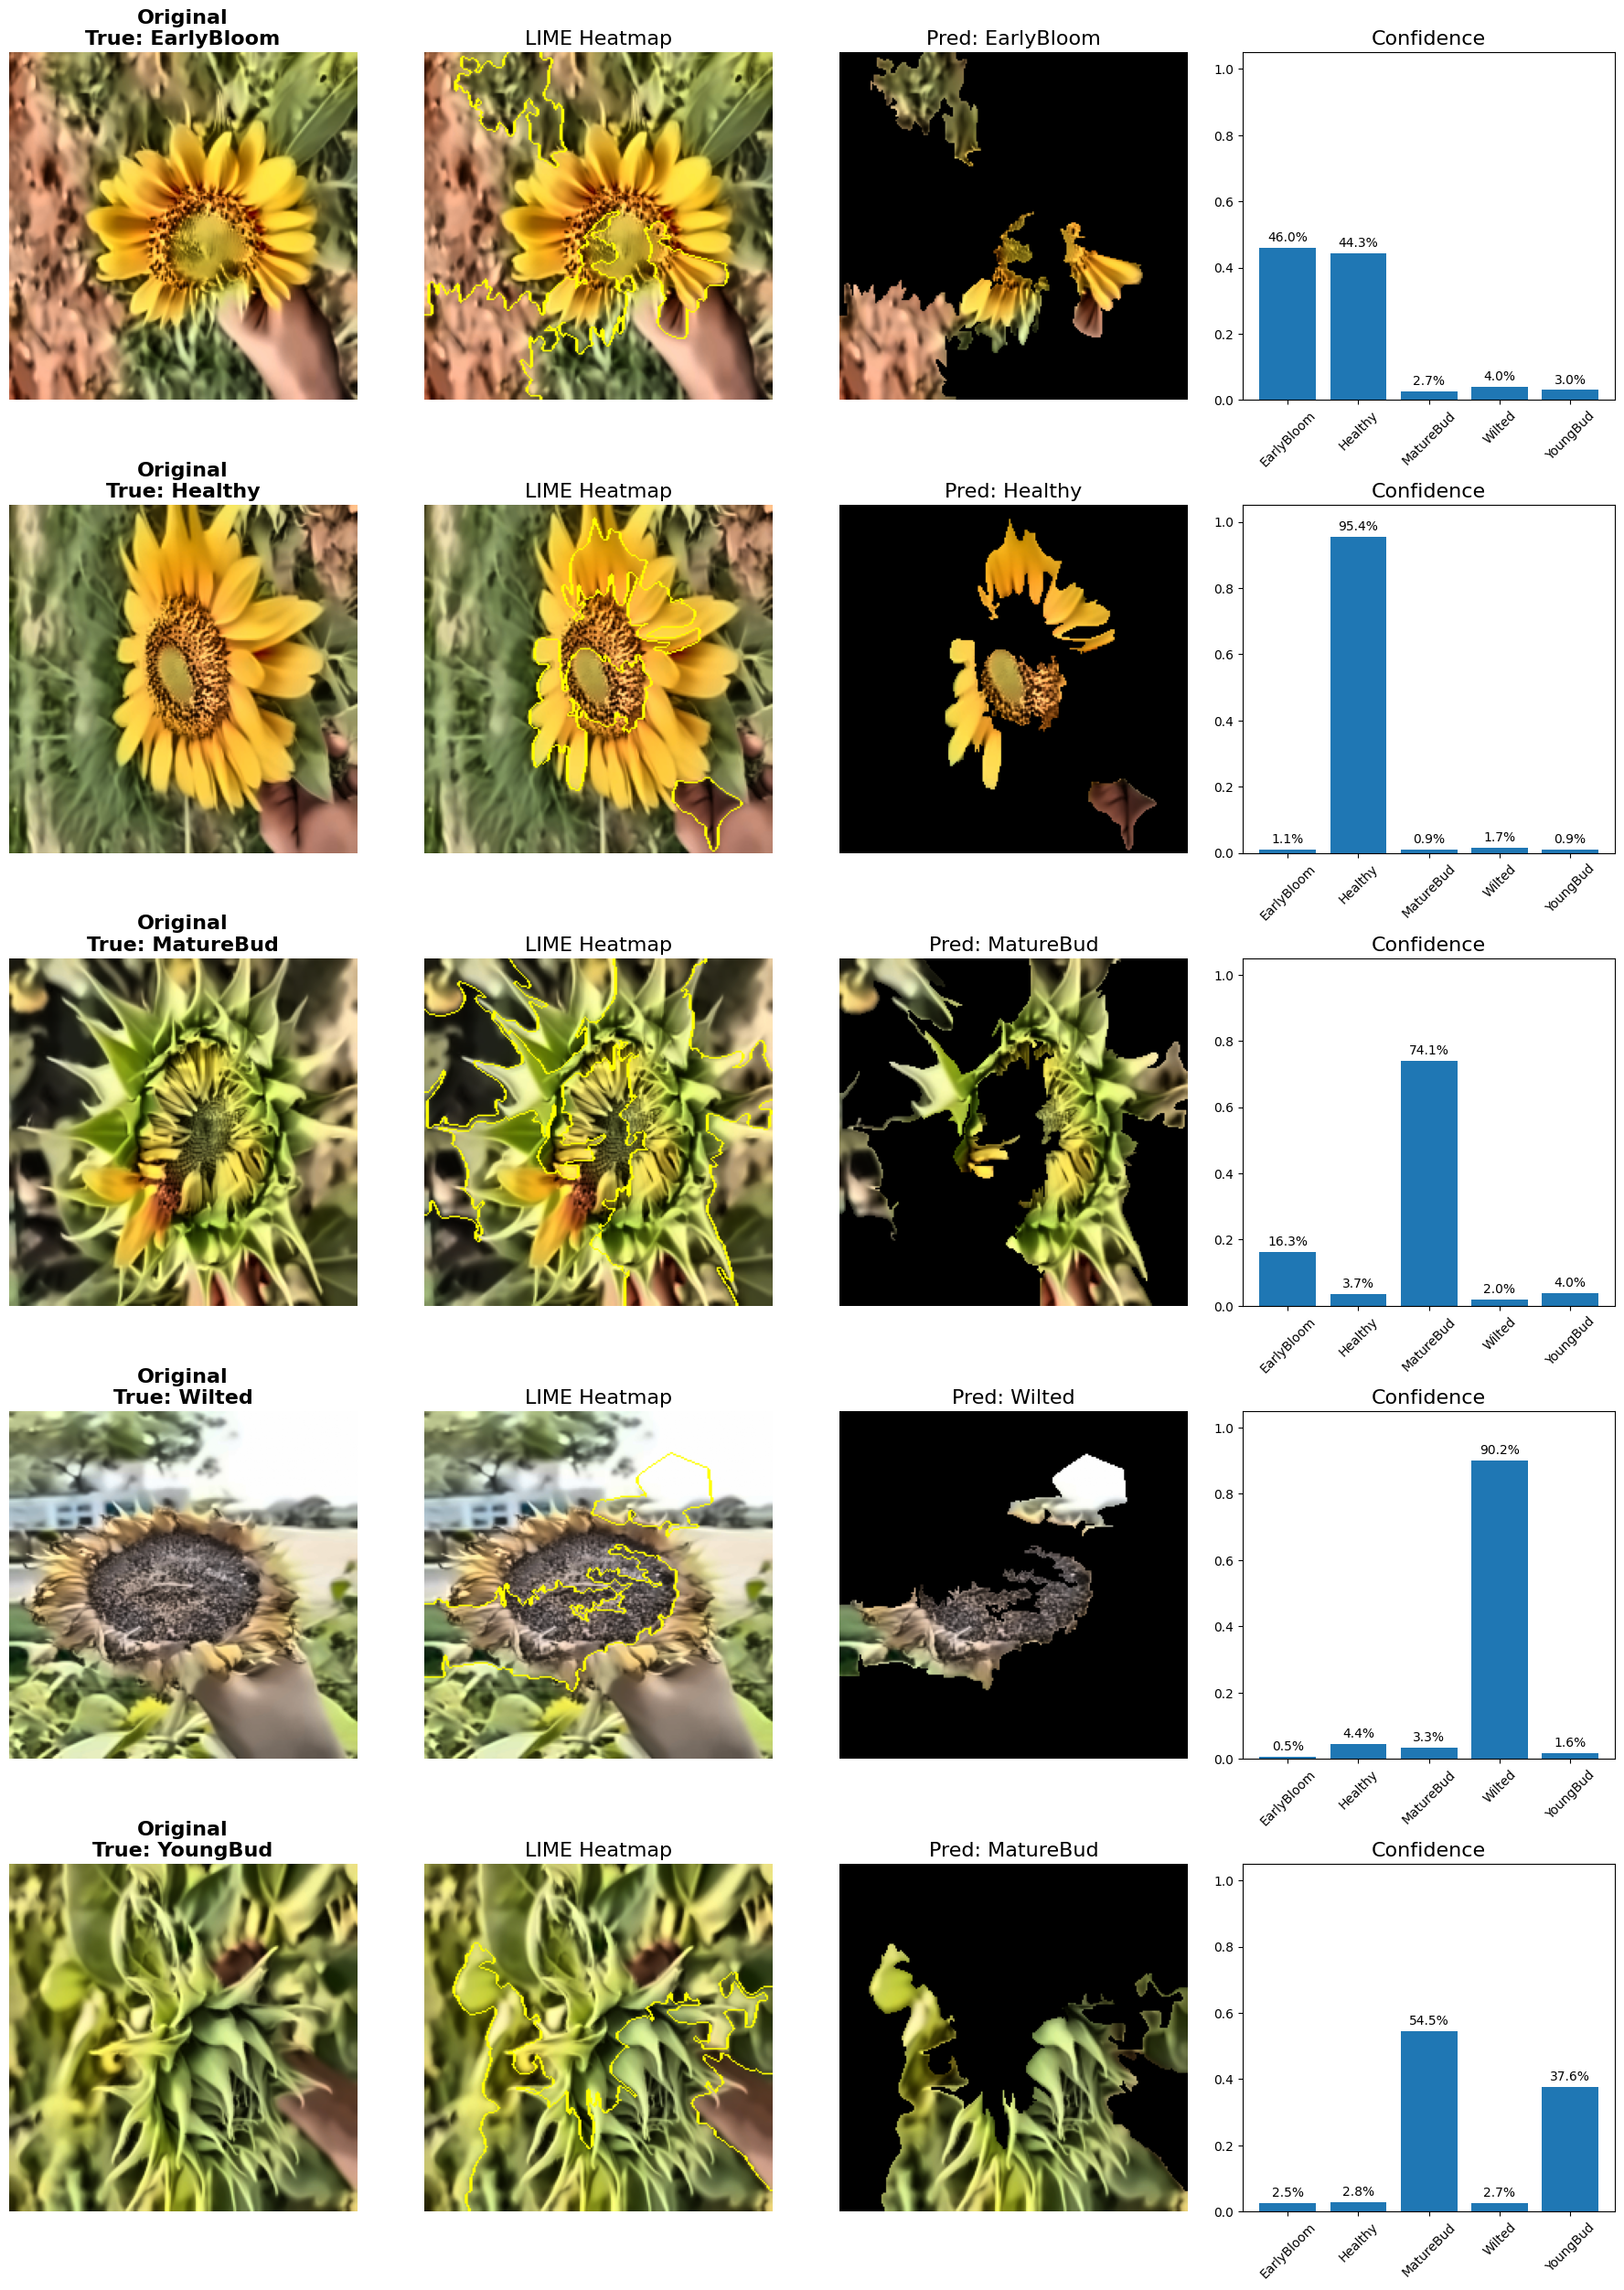

In [18]:
!pip install lime -q

import torch
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from scipy.stats import ttest_rel

model.eval()

def predict_fn(images):

    images = torch.tensor(images).permute(0, 3, 1, 2).float()
    images = (images - 0.5) / 0.5
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()


def mask_to_binary(mask):
    return (mask > 0).astype(np.uint8)

def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union != 0 else 0


num_classes = len(class_names)

images_store = {}
probs_store = {}
lime_masks = {}
lime_imgs = {}

iou_scores = []
baseline_scores = []

explainer = lime_image.LimeImageExplainer()

segmentation_fn = lambda x: slic(x, n_segments=50, compactness=10, sigma=1)

class_to_indices = {i: [] for i in range(num_classes)}

for idx in range(len(test_ds)):
    _, label = test_ds[idx]
    class_to_indices[label].append(idx)

selected_indices = {
    cls: np.random.choice(indices)
    for cls, indices in class_to_indices.items()
}

for label, idx in selected_indices.items():

    image, _ = test_ds[idx]

    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)

    explanation = explainer.explain_instance(
        img,
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=30,
        segmentation_fn=segmentation_fn
    )

    pred_class = explanation.top_labels[0]

    temp, mask = explanation.get_image_and_mask(
        pred_class,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    probs = predict_fn(np.expand_dims(img, axis=0))[0]

    pred_mask = mask_to_binary(mask)

    h, w = pred_mask.shape
    gt_mask = np.zeros_like(pred_mask)

    gt_mask[h//4:3*h//4, w//4:3*w//4] = 1

    iou = compute_iou(pred_mask, gt_mask)
    iou_scores.append(iou)

    baseline_mask = (mask > 1).astype(np.uint8)
    baseline_iou = compute_iou(baseline_mask, gt_mask)
    baseline_scores.append(baseline_iou)

    images_store[label] = img
    lime_masks[label] = mask
    lime_imgs[label] = temp
    probs_store[label] = probs


iou_scores = np.array(iou_scores)
baseline_scores = np.array(baseline_scores)

mean_iou = np.mean(iou_scores)

t_stat, p_value = ttest_rel(iou_scores, baseline_scores)

print("\n=== LIME METRICS ===")
print("Mean IoU:", round(mean_iou, 4))
print("\nPaired t-test Results")
print("t-statistic:", round(t_stat, 4))

if p_value < 1e-6:
    print("p-value: < 1e-6")
else:
    print("p-value:", p_value)


TITLE_SIZE = 16

fig, axes = plt.subplots(num_classes, 4, figsize=(18, 5 * num_classes))

for idx, label in enumerate(sorted(images_store.keys())):

    img = images_store[label]
    mask = lime_masks[label]
    temp = lime_imgs[label]
    probs = probs_store[label]

    pred_class = np.argmax(probs)

    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(
        f"Original\nTrue: {class_names[label]}",
        fontsize=TITLE_SIZE,
        fontweight='bold'
    )
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(mark_boundaries(temp, mask))
    axes[idx, 1].set_title("LIME Heatmap", fontsize=TITLE_SIZE)
    axes[idx, 1].axis('off')

    masked = np.zeros_like(img)
    masked[mask > 0] = img[mask > 0]

    axes[idx, 2].imshow(masked)
    axes[idx, 2].set_title(
        f"Pred: {class_names[pred_class]}",
        fontsize=TITLE_SIZE
    )
    axes[idx, 2].axis('off')

    bars = axes[idx, 3].bar(range(len(class_names)), probs)

    axes[idx, 3].set_ylim(0, 1.05)
    axes[idx, 3].set_title("Confidence", fontsize=TITLE_SIZE)

    axes[idx, 3].set_xticks(range(len(class_names)))
    axes[idx, 3].set_xticklabels(class_names, rotation=45)

    for bar, v in zip(bars, probs):
        axes[idx, 3].text(
            bar.get_x() + bar.get_width()/2,
            v + 0.02,
            f"{v*100:.1f}%",
            ha='center'
        )

plt.tight_layout()
plt.show()

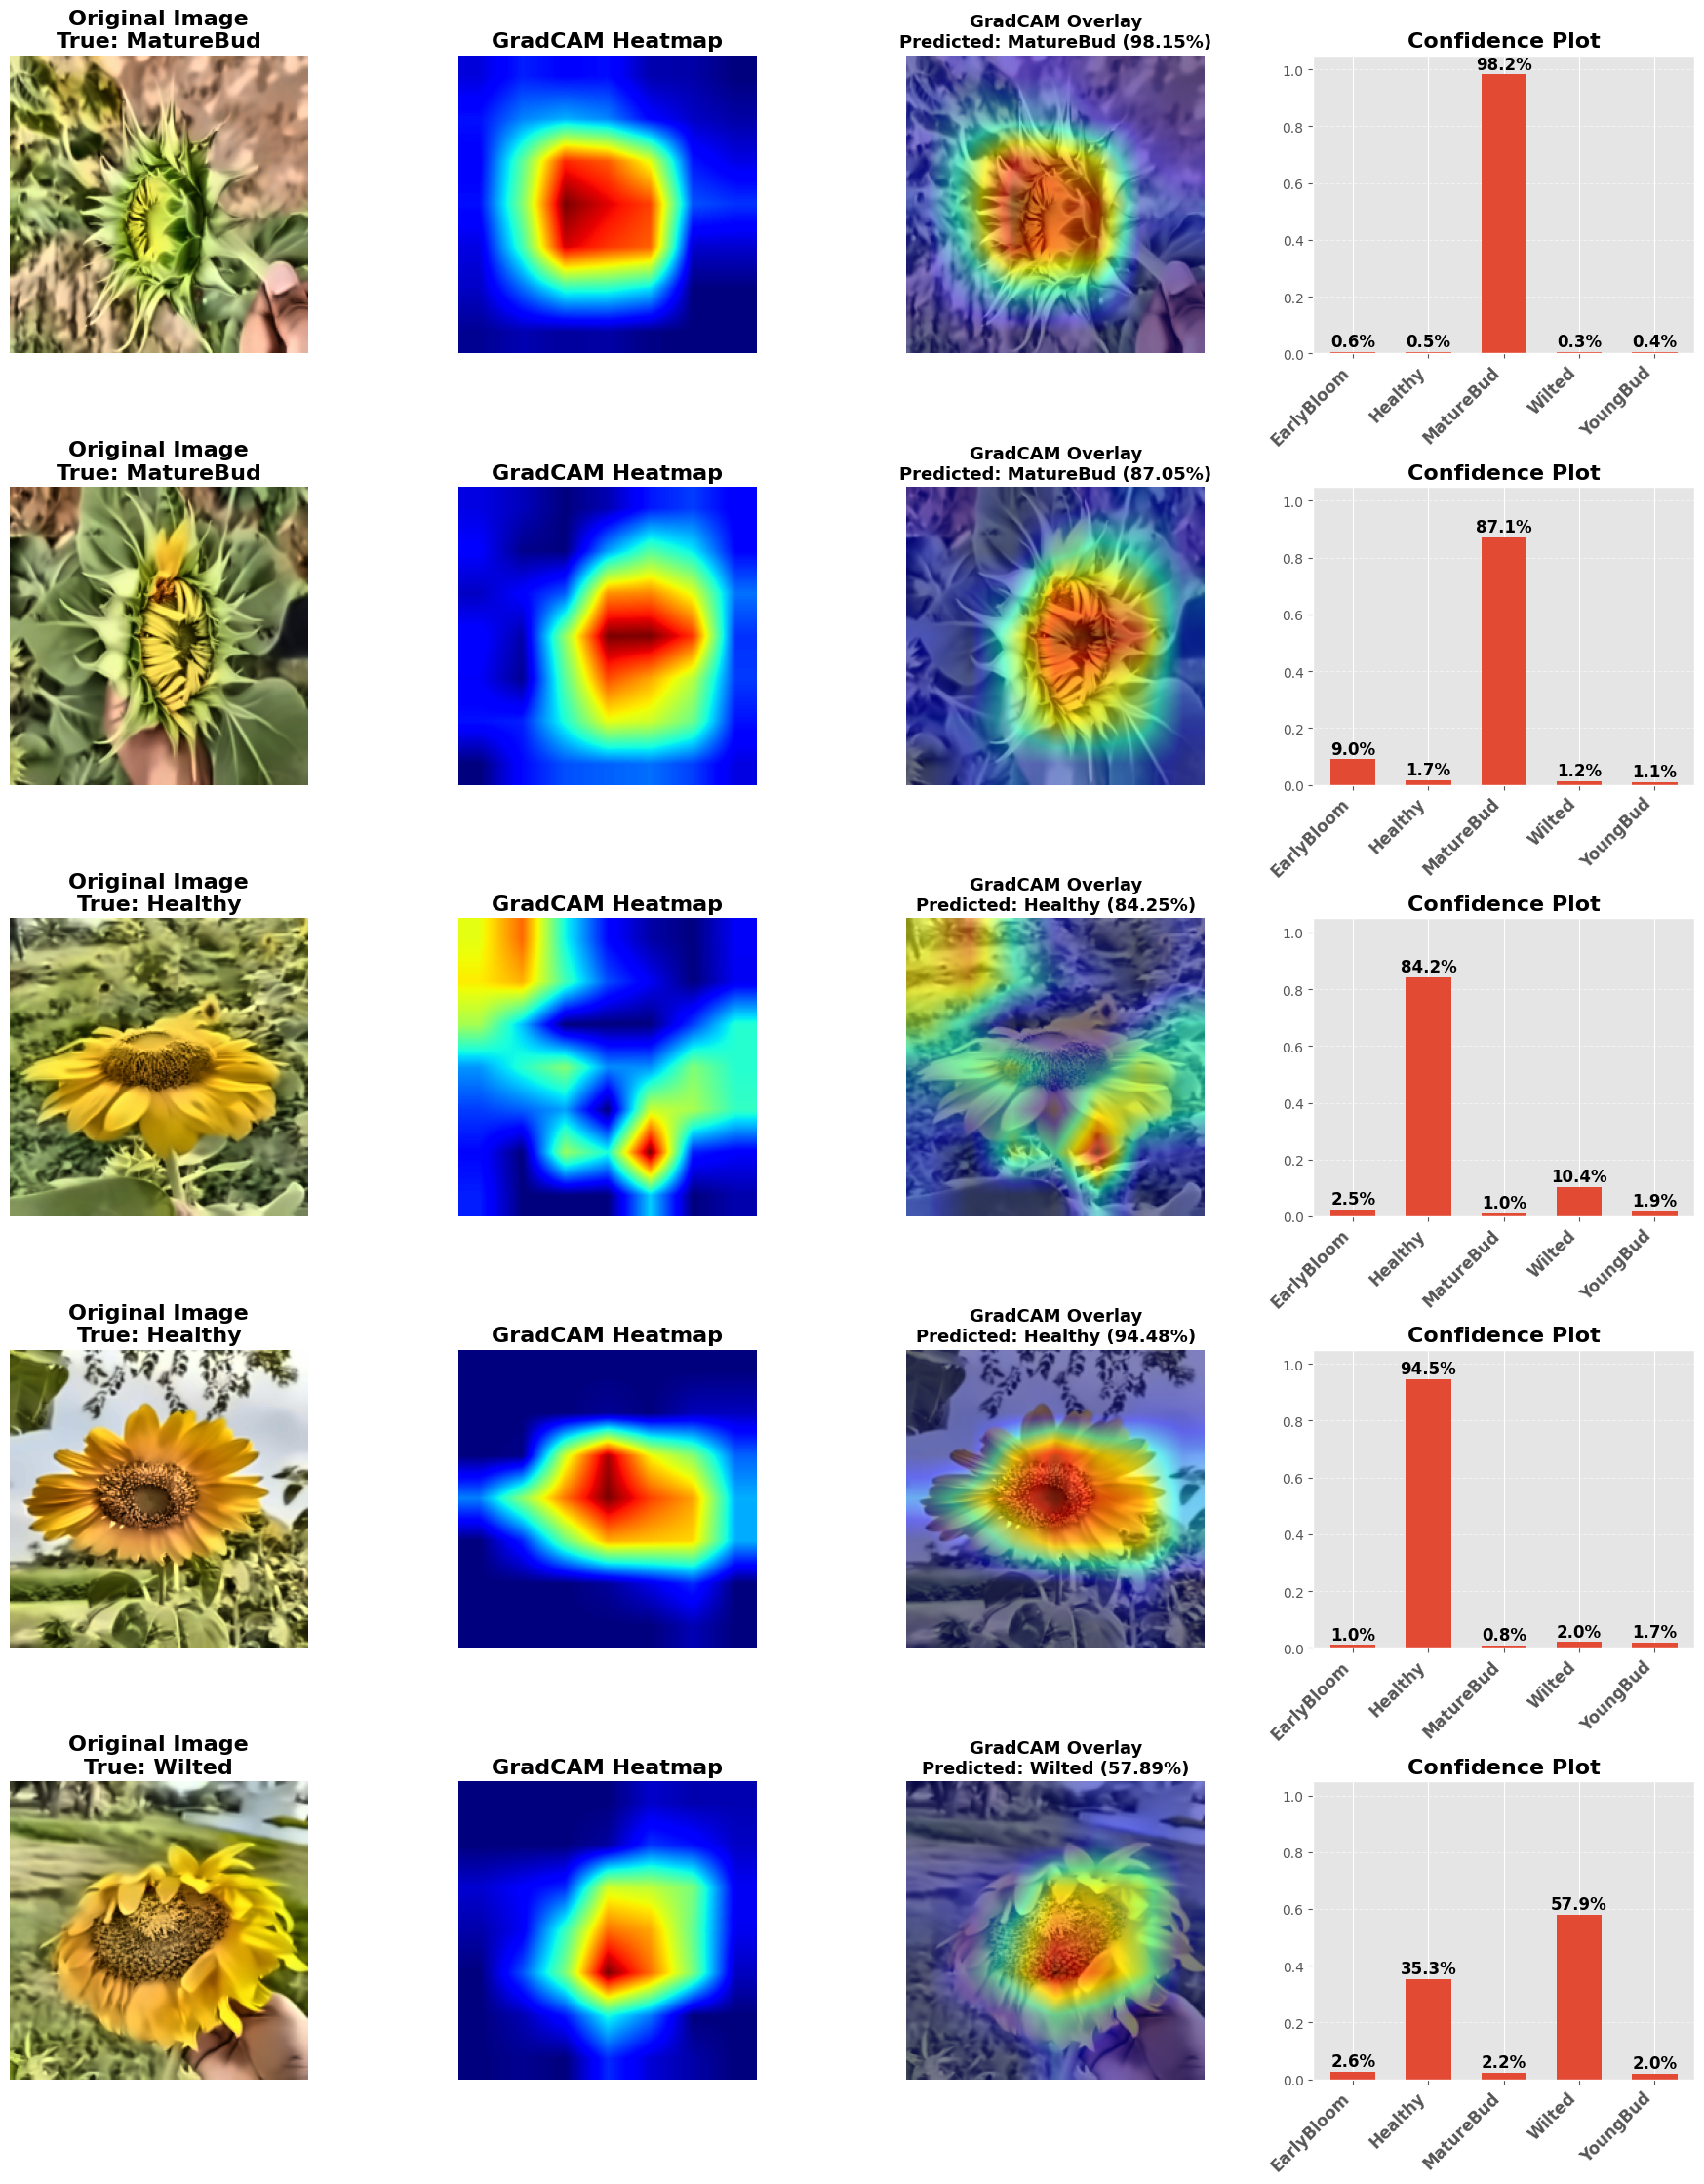


=== Grad-CAM METRICS ===
Mean IoU: 0.4982

Paired t-test Results
t-statistic: 4.2866
p-value: 0.012780932286689162


In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.stats import ttest_rel

model.eval()

def heatmap_to_mask(cam, threshold=0.5):
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    return (cam > threshold).astype(np.uint8)

def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union != 0 else 0

def generate_gradcam(image_tensor):

    image_tensor = image_tensor.unsqueeze(0).to(device)
    image_tensor.requires_grad = True

    d_features = model.densenet(image_tensor)[-1]

    d_features.requires_grad_(True)
    d_features.retain_grad()

    pooled = model.pool(d_features).view(image_tensor.size(0), -1)
    d_proj = model.proj_d(pooled)

    v_feat = model.vit(image_tensor)
    v_proj = model.proj_v(v_feat)

    fused = model.fusion(d_proj, v_proj)
    output = model.classifier(fused)

    probs = torch.softmax(output, dim=1)
    pred_class = probs.argmax(dim=1).item()
    confidence = probs[0, pred_class].item()

    model.zero_grad()
    output[0, pred_class].backward()

    grads = d_features.grad[0].cpu().detach().numpy()
    acts = d_features[0].cpu().detach().numpy()

    weights = np.mean(grads, axis=(1, 2))

    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam -= cam.min()
    cam /= (cam.max() + 1e-8)

    cam = cv2.resize(cam, (image_size[0], image_size[1]))

    return cam, pred_class, confidence, probs.detach().cpu().numpy()[0]

def show_results(dataset, num_samples=5):

    class_names = ['EarlyBloom', 'Healthy', 'MatureBud', 'Wilted', 'YoungBud']

    plt.style.use('ggplot')

    fig, axes = plt.subplots(
        num_samples,
        4,
        figsize=(18, 4.5 * num_samples)
    )

    indices = np.random.choice(
        len(dataset),
        num_samples,
        replace=False
    )

    iou_scores = []
    baseline_scores = []

    for i, idx in enumerate(indices):

        image, label = dataset[idx]

        cam, pred, conf, probs = generate_gradcam(image)

        conf_percent = conf * 100

        img = image.permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5) + 0.5
        img = np.clip(img, 0, 1)

        heatmap = cv2.applyColorMap(
            np.uint8(255 * cam),
            cv2.COLORMAP_JET
        )

        heatmap = cv2.cvtColor(
            heatmap,
            cv2.COLOR_BGR2RGB
        ) / 255

        overlay = heatmap * 0.5 + img * 0.5
        overlay = np.clip(overlay, 0, 1)

        pred_mask = heatmap_to_mask(
            cam,
            threshold=0.5
        )

        h, w = pred_mask.shape

        gt_mask = np.zeros_like(pred_mask)
        gt_mask[
            h//4:3*h//4,
            w//4:3*w//4
        ] = 1

        iou = compute_iou(
            pred_mask,
            gt_mask
        )

        iou_scores.append(iou)

        baseline_mask = heatmap_to_mask(
            cam,
            threshold=0.7
        )

        baseline_iou = compute_iou(
            baseline_mask,
            gt_mask
        )

        baseline_scores.append(baseline_iou)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(
            f"Original Image\nTrue: {class_names[label]}",
            fontsize=16,
            fontweight='bold'
        )
        axes[i, 0].axis('off')

        axes[i, 1].imshow(cam, cmap='jet')
        axes[i, 1].set_title(
            "GradCAM Heatmap",
            fontsize=16,
            fontweight='bold'
        )
        axes[i, 1].axis('off')

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(
            f"GradCAM Overlay\nPredicted: {class_names[pred]} ({conf_percent:.2f}%)",
            fontsize=13,
            fontweight='bold'
        )
        axes[i, 2].axis('off')

        bars = axes[i, 3].bar(
            range(len(class_names)),
            probs,
            width=0.6
        )

        axes[i, 3].set_ylim(0, 1.05)
        axes[i, 3].set_title(
            "Confidence Plot",
            fontsize=16,
            fontweight='bold'
        )

        axes[i, 3].set_xticks(
            range(len(class_names))
        )

        axes[i, 3].set_xticklabels(
            class_names,
            rotation=45,
            ha='right',
            fontsize=12,
            fontweight='bold'
        )

        for bar, v in zip(bars, probs):
            axes[i, 3].text(
                bar.get_x() + bar.get_width()/2,
                v + 0.02,
                f"{v*100:.1f}%",
                ha='center',
                fontsize=12,
                fontweight='bold'
            )

        axes[i, 3].grid(
            axis='y',
            linestyle='--',
            alpha=0.5
        )

    plt.tight_layout()
    plt.show()

    iou_scores = np.array(iou_scores)
    baseline_scores = np.array(baseline_scores)

    mean_iou = np.mean(iou_scores)

    t_stat, p_value = ttest_rel(
        iou_scores,
        baseline_scores
    )

    print("\n=== Grad-CAM METRICS ===")
    print("Mean IoU:", round(mean_iou, 4))
    print("\nPaired t-test Results")
    print("t-statistic:", round(t_stat, 4))

    if p_value < 1e-6:
        print("p-value: < 1e-6")
    else:
        print("p-value:", p_value)

show_results(test_ds, num_samples=5)

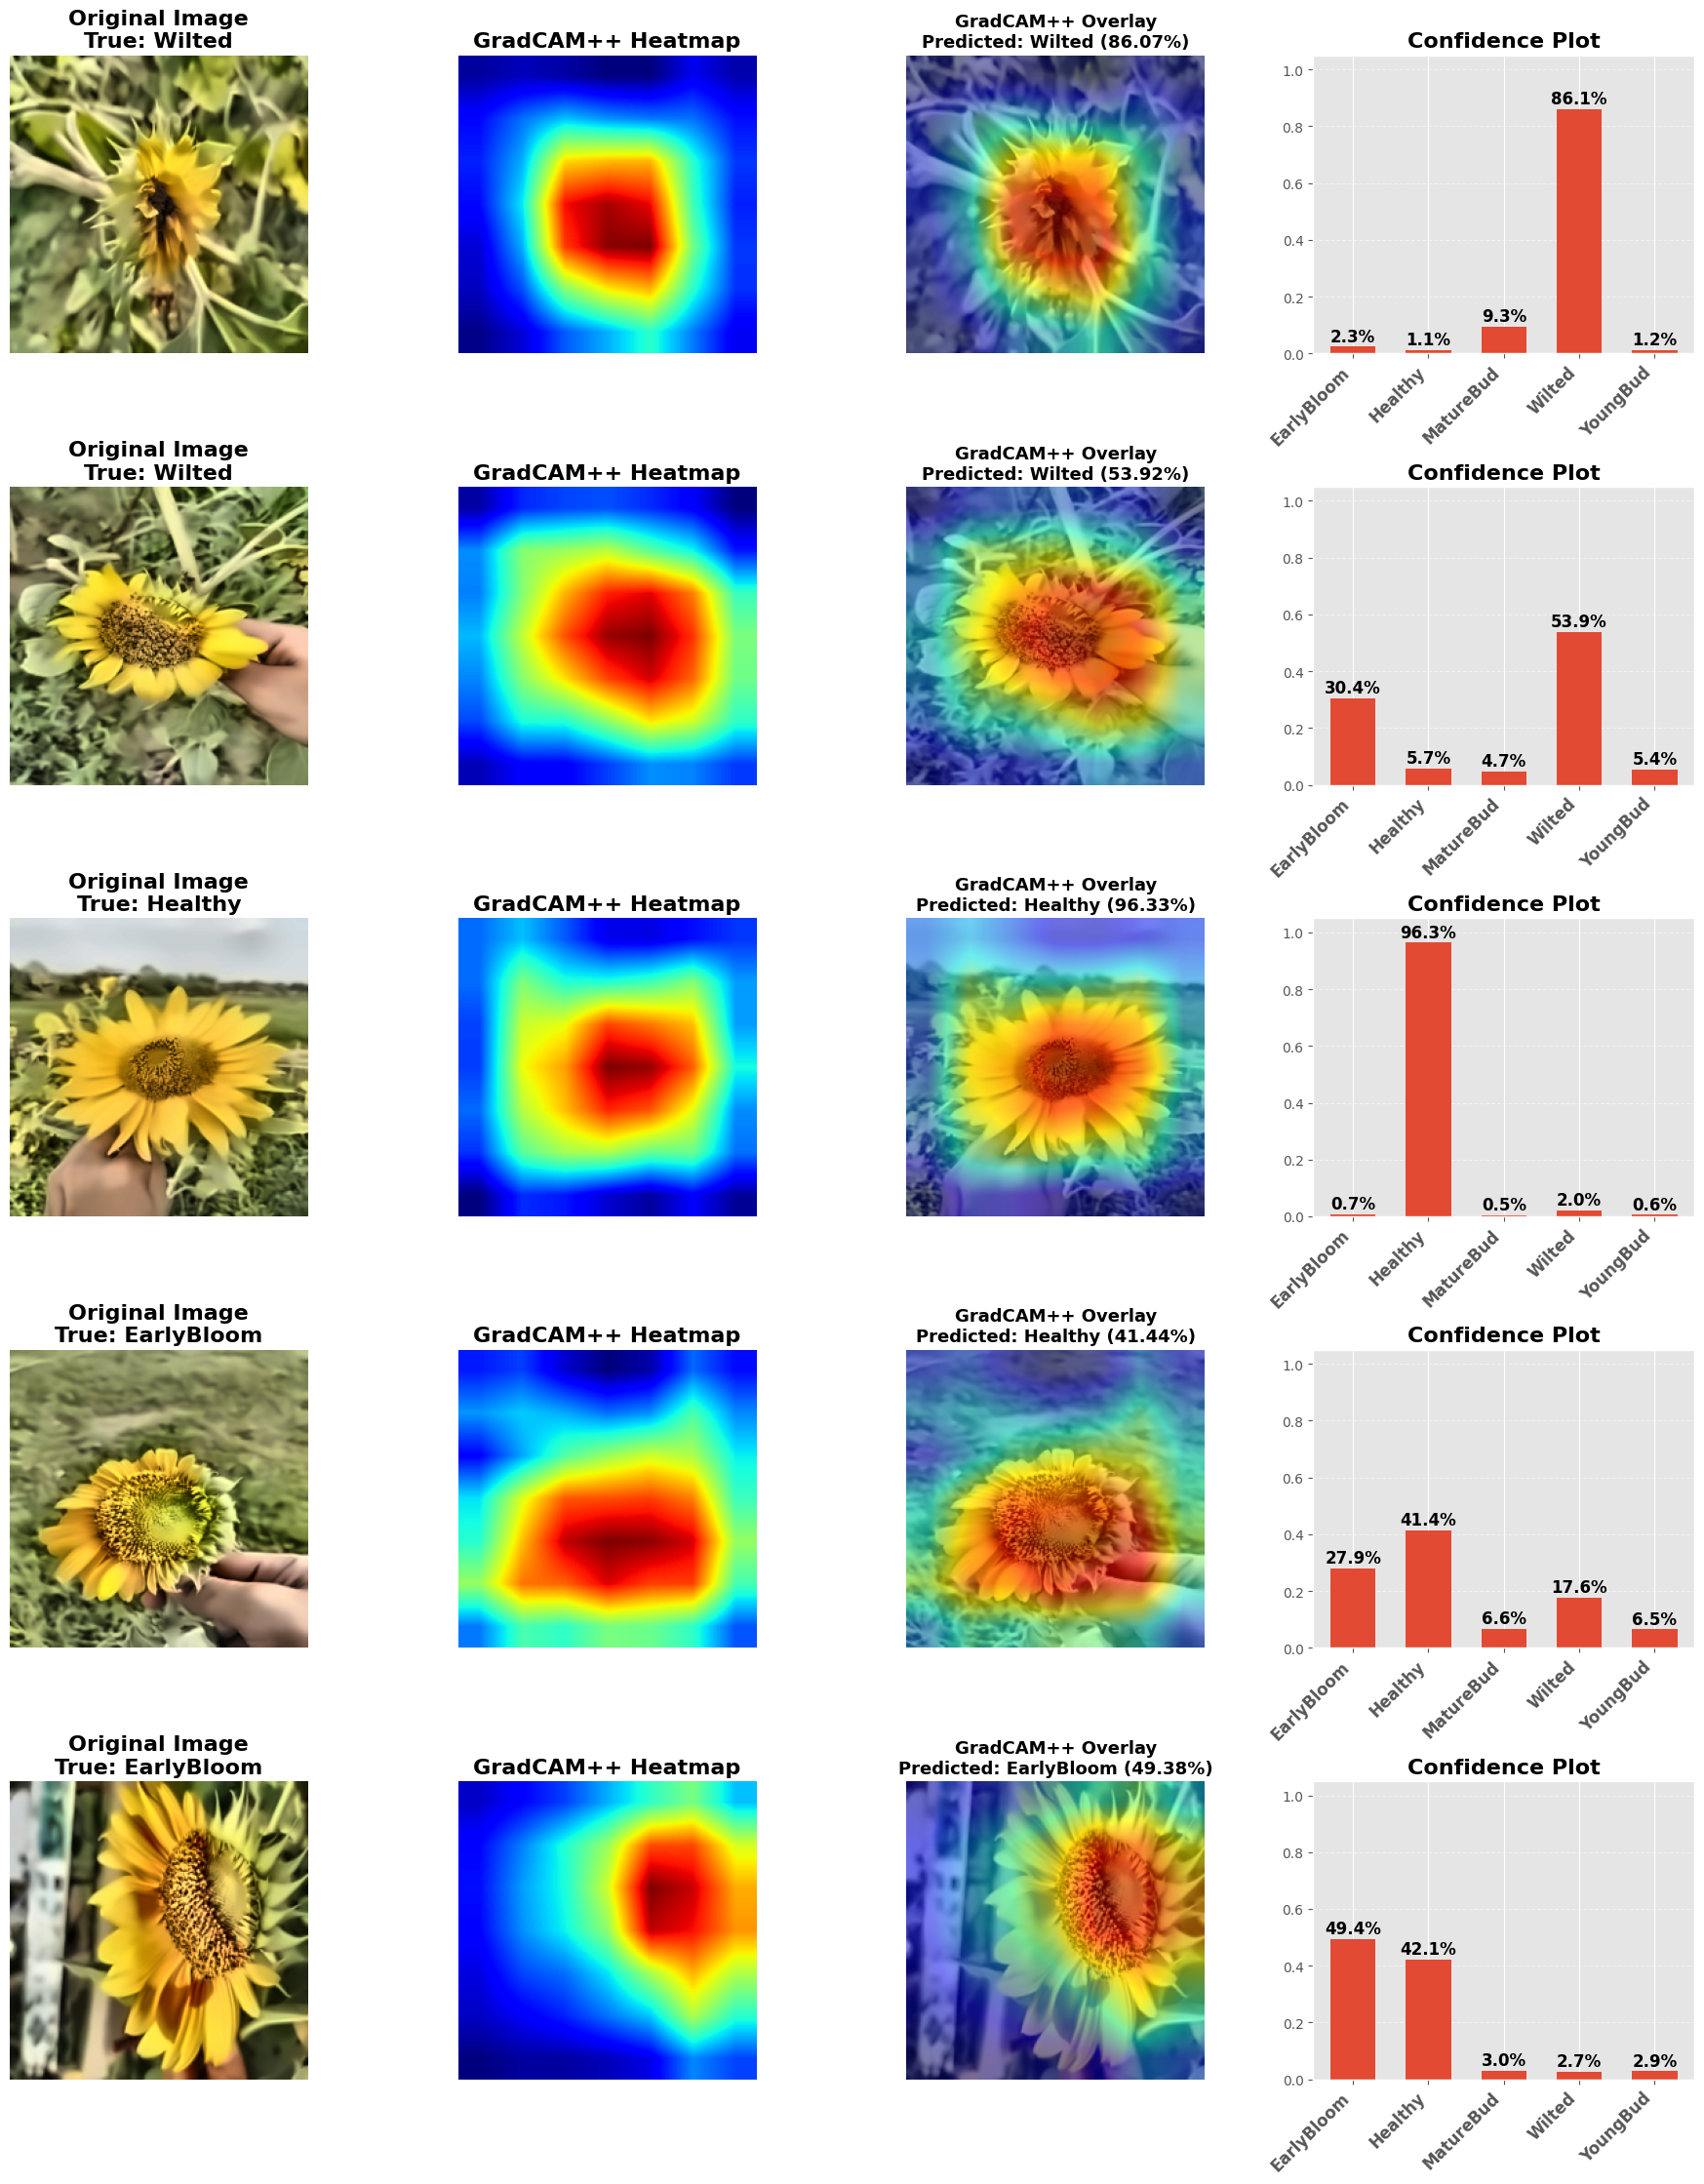


=== Grad-CAM++ METRICS ===
Mean IoU: 0.5427

Paired t-test Results
t-statistic: 1.7765
p-value: 0.1502876941781045
✅ FINAL COMPLETE — GradCAM++ + IoU + T-TEST


In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.stats import ttest_rel

model.eval()

def heatmap_to_mask(cam, threshold=0.5):
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    return (cam > threshold).astype(np.uint8)

def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union != 0 else 0

def generate_gradcam(image_tensor):

    image_tensor = image_tensor.unsqueeze(0).to(device)
    image_tensor.requires_grad = True

    d_features = model.densenet(image_tensor)[-1]

    d_features.requires_grad_(True)
    d_features.retain_grad()

    pooled = model.pool(d_features).view(image_tensor.size(0), -1)
    d_proj = model.proj_d(pooled)

    v_feat = model.vit(image_tensor)
    v_proj = model.proj_v(v_feat)

    fused = model.fusion(d_proj, v_proj)
    output = model.classifier(fused)

    probs = torch.softmax(output, dim=1)
    pred_class = probs.argmax(dim=1).item()
    confidence = probs[0, pred_class].item()

    model.zero_grad()
    output[0, pred_class].backward()

    grads = d_features.grad[0]
    acts = d_features[0]

    grads_power_2 = grads ** 2
    grads_power_3 = grads_power_2 * grads

    sum_acts = torch.sum(
        acts.view(acts.shape[0], -1),
        dim=1,
        keepdim=True
    ).view(-1, 1, 1)

    eps = 1e-8

    alpha = grads_power_2 / (
        2 * grads_power_2 +
        sum_acts * grads_power_3 +
        eps
    )

    positive_grad = torch.relu(grads)

    weights = torch.sum(alpha * positive_grad, dim=(1, 2))

    cam = torch.zeros(
        acts.shape[1:],
        dtype=torch.float32
    ).to(device)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + eps)

    cam = cam.cpu().detach().numpy()
    cam = cv2.resize(
        cam,
        (image_size[0], image_size[1])
    )

    return (
        cam,
        pred_class,
        confidence,
        probs.detach().cpu().numpy()[0]
    )

def show_results(dataset, num_samples=5):

    class_names = [
        'EarlyBloom',
        'Healthy',
        'MatureBud',
        'Wilted',
        'YoungBud'
    ]

    plt.style.use('ggplot')

    fig, axes = plt.subplots(
        num_samples,
        4,
        figsize=(18, 4.5 * num_samples)
    )

    indices = np.random.choice(
        len(dataset),
        num_samples,
        replace=False
    )

    iou_scores = []
    baseline_scores = []

    for i, idx in enumerate(indices):

        image, label = dataset[idx]

        cam, pred, conf, probs = generate_gradcam(image)

        conf_percent = conf * 100

        img = image.permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5) + 0.5
        img = np.clip(img, 0, 1)

        heatmap = cv2.applyColorMap(
            np.uint8(255 * cam),
            cv2.COLORMAP_JET
        )

        heatmap = cv2.cvtColor(
            heatmap,
            cv2.COLOR_BGR2RGB
        ) / 255

        overlay = heatmap * 0.5 + img * 0.5
        overlay = np.clip(overlay, 0, 1)

        pred_mask = heatmap_to_mask(cam, 0.5)

        h, w = pred_mask.shape
        gt_mask = np.zeros_like(pred_mask)
        gt_mask[
            h//4:3*h//4,
            w//4:3*w//4
        ] = 1

        iou_scores.append(
            compute_iou(pred_mask, gt_mask)
        )

        baseline_mask = heatmap_to_mask(cam, 0.7)

        baseline_scores.append(
            compute_iou(baseline_mask, gt_mask)
        )

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(
            f"Original Image\nTrue: {class_names[label]}",
            fontsize=16,
            fontweight='bold'
        )
        axes[i, 0].axis('off')

        axes[i, 1].imshow(cam, cmap='jet')
        axes[i, 1].set_title(
            "GradCAM++ Heatmap",
            fontsize=16,
            fontweight='bold'
        )
        axes[i, 1].axis('off')

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(
            f"GradCAM++ Overlay\nPredicted: "
            f"{class_names[pred]} ({conf_percent:.2f}%)",
            fontsize=13,
            fontweight='bold'
        )
        axes[i, 2].axis('off')

        bars = axes[i, 3].bar(
            range(len(class_names)),
            probs,
            width=0.6
        )

        axes[i, 3].set_ylim(0, 1.05)
        axes[i, 3].set_title(
            "Confidence Plot",
            fontsize=16,
            fontweight='bold'
        )

        axes[i, 3].set_xticks(
            range(len(class_names))
        )

        axes[i, 3].set_xticklabels(
            class_names,
            rotation=45,
            ha='right',
            fontsize=12,
            fontweight='bold'
        )

        for bar, v in zip(bars, probs):
            axes[i, 3].text(
                bar.get_x() + bar.get_width() / 2,
                v + 0.02,
                f"{v*100:.1f}%",
                ha='center',
                fontsize=12,
                fontweight='bold'
            )

        axes[i, 3].grid(
            axis='y',
            linestyle='--',
            alpha=0.5
        )

    plt.tight_layout()
    plt.show()

    iou_scores = np.array(iou_scores)
    baseline_scores = np.array(baseline_scores)

    mean_iou = np.mean(iou_scores)

    t_stat, p_value = ttest_rel(
        iou_scores,
        baseline_scores
    )

    print("\n=== Grad-CAM++ METRICS ===")
    print("Mean IoU:", round(mean_iou, 4))

    print("\nPaired t-test Results")
    print("t-statistic:", round(t_stat, 4))

    if p_value < 1e-6:
        print("p-value: < 1e-6")
    else:
        print("p-value:", p_value)

show_results(test_ds, num_samples=5)

  0%|          | 0/30 [00:00<?, ?it/s]

Sample 1/5 | True: YoungBud | LIME: 0.1907 | Grad-CAM: 0.6398 | Grad-CAM++: 0.4953


  0%|          | 0/30 [00:00<?, ?it/s]

Sample 2/5 | True: Wilted | LIME: 0.1190 | Grad-CAM: 0.6728 | Grad-CAM++: 0.6430


  0%|          | 0/30 [00:00<?, ?it/s]

Sample 3/5 | True: Healthy | LIME: 0.0562 | Grad-CAM: 0.4266 | Grad-CAM++: 0.6505


  0%|          | 0/30 [00:00<?, ?it/s]

Sample 4/5 | True: EarlyBloom | LIME: 0.1147 | Grad-CAM: 0.4554 | Grad-CAM++: 0.5729


  0%|          | 0/30 [00:00<?, ?it/s]

Sample 5/5 | True: EarlyBloom | LIME: 0.0545 | Grad-CAM: 0.4692 | Grad-CAM++: 0.5110

FINAL EXPLAINABILITY COMPARISON

Mean IoU:
LIME       : 0.1070
Grad-CAM   : 0.5327
Grad-CAM++ : 0.5746

Paired t-test Results:

Grad-CAM vs LIME
t-statistic: 11.5124
raw p-value: 0.000325

Grad-CAM++ vs Grad-CAM
t-statistic: 0.6663
raw p-value: 0.541675

Grad-CAM++ vs LIME
t-statistic: 9.7460
raw p-value: 0.000621

BONFERRONI-CORRECTED RESULTS

Grad-CAM vs LIME: adjusted p = 0.000975
Grad-CAM++ vs Grad-CAM: adjusted p = 1.000000
Grad-CAM++ vs LIME: adjusted p = 0.001862

Significance:
Grad-CAM vs LIME: Significant (p < 0.05)
Grad-CAM++ vs Grad-CAM: Not significant (p >= 0.05)
Grad-CAM++ vs LIME: Significant (p < 0.05)


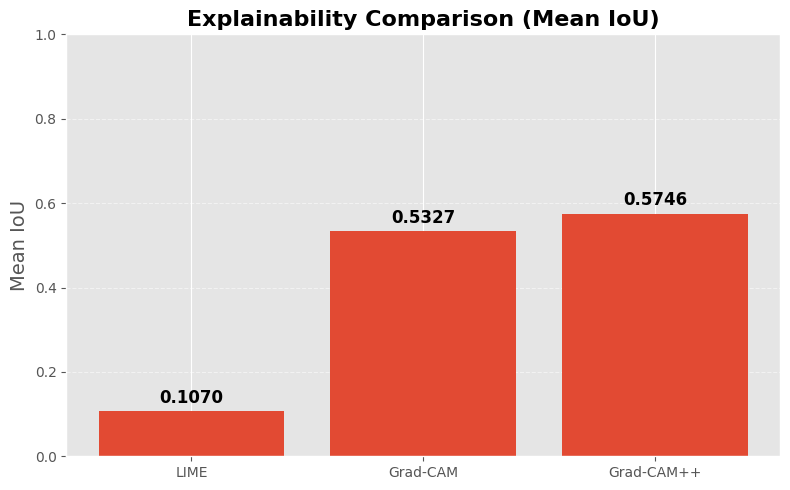


✅ FINAL COMPLETE
LIME + Grad-CAM + Grad-CAM++
IoU + Paired t-test + Bonferroni Correction


In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
from scipy.stats import ttest_rel
from lime import lime_image

model.eval()

class_names = [
    'EarlyBloom',
    'Healthy',
    'MatureBud',
    'Wilted',
    'YoungBud'
]

num_samples = 5

indices = np.random.choice(
    len(test_ds),
    num_samples,
    replace=False
)

lime_iou_scores = []
gradcam_iou_scores = []
gradcampp_iou_scores = []


def heatmap_to_mask(cam, threshold=0.5):
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    return (cam > threshold).astype(np.uint8)


def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    return intersection / union if union != 0 else 0


def create_pseudo_gt(cam):
    h, w = cam.shape

    gt_mask = np.zeros_like(cam, dtype=np.uint8)

    gt_mask[
        h // 4:3 * h // 4,
        w // 4:3 * w // 4
    ] = 1

    return gt_mask


def predict_for_lime(images):
    model.eval()

    batch = []

    for img in images:

        img = cv2.cvtColor(
            img.astype(np.float32),
            cv2.COLOR_RGB2BGR
        )

        tensor = torch.tensor(
            img,
            dtype=torch.float32
        ).permute(2, 0, 1)

        tensor = tensor.unsqueeze(0)

        tensor = tensor.to(device)

        batch.append(tensor)

    batch = torch.cat(batch, dim=0)

    batch = (batch - 0.5) / 0.5

    with torch.no_grad():

        output = model(batch)

        if isinstance(output, tuple):
            output = output[0]

        probabilities = torch.softmax(
            output,
            dim=1
        )

    return probabilities.cpu().numpy()


def generate_gradcam(image_tensor, method='gradcam'):

    model.eval()

    image_tensor = image_tensor.unsqueeze(0).to(device)

    image_tensor.requires_grad_(True)

    model.zero_grad()

    d_features = model.densenet(
        image_tensor
    )[-1]

    d_features.retain_grad()

    pooled = model.pool(
        d_features
    ).view(
        image_tensor.size(0),
        -1
    )

    d_proj = model.proj_d(
        pooled
    )

    v_feat = model.vit(
        image_tensor
    )

    v_proj = model.proj_v(
        v_feat
    )

    fused = model.fusion(
        d_proj,
        v_proj
    )

    output = model.classifier(
        fused
    )

    probs = torch.softmax(
        output,
        dim=1
    )

    pred_class = probs.argmax(
        dim=1
    ).item()

    confidence = probs[
        0,
        pred_class
    ].item()

    output[
        0,
        pred_class
    ].backward()

    grads = d_features.grad[0]

    acts = d_features[0]

    if method == 'gradcam':

        weights = grads.mean(
            dim=(1, 2)
        )

    elif method == 'gradcampp':

        grads_power_2 = grads ** 2

        grads_power_3 = grads_power_2 * grads

        sum_acts = torch.sum(
            acts.view(
                acts.shape[0],
                -1
            ),
            dim=1,
            keepdim=True
        ).view(
            -1,
            1,
            1
        )

        eps = 1e-8

        alpha = grads_power_2 / (
            2 * grads_power_2
            + sum_acts * grads_power_3
            + eps
        )

        positive_grad = torch.relu(
            grads
        )

        weights = torch.sum(
            alpha * positive_grad,
            dim=(1, 2)
        )

    cam = torch.zeros(
        acts.shape[1:],
        dtype=torch.float32,
        device=device
    )

    for i, weight in enumerate(weights):

        cam += weight * acts[i]

    cam = torch.relu(cam)

    cam = cam - cam.min()

    cam = cam / (
        cam.max() + 1e-8
    )

    cam = cam.detach().cpu().numpy()

    cam = cv2.resize(
        cam,
        (
            image_size[0],
            image_size[1]
        )
    )

    return (
        cam,
        pred_class,
        confidence,
        probs.detach().cpu().numpy()[0]
    )


def generate_lime_iou(image_tensor):

    img = image_tensor.permute(
        1,
        2,
        0
    ).cpu().numpy()

    img = (img * 0.5) + 0.5

    img = np.clip(
        img,
        0,
        1
    )

    img_uint8 = (
        img * 255
    ).astype(
        np.uint8
    )

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        img_uint8,
        predict_for_lime,
        top_labels=5,
        hide_color=0,
        num_samples=30
    )

    pred_class = explanation.top_labels[0]

    _, lime_mask = explanation.get_image_and_mask(
        pred_class,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    lime_mask = (
        lime_mask > 0
    ).astype(
        np.uint8
    )

    lime_mask = cv2.resize(
        lime_mask,
        (
            image_size[0],
            image_size[1]
        ),
        interpolation=cv2.INTER_NEAREST
    )

    return lime_mask, pred_class, img


for sample_number, idx in enumerate(indices):

    image, label = test_ds[idx]

    cam_gradcam, pred_gc, conf_gc, probs_gc = generate_gradcam(
        image,
        method='gradcam'
    )

    cam_gradcampp, pred_gcpp, conf_gcpp, probs_gcpp = generate_gradcam(
        image,
        method='gradcampp'
    )

    lime_mask, pred_lime, original_img = generate_lime_iou(
        image
    )

    gt_mask = create_pseudo_gt(
        cam_gradcam
    )

    gradcam_mask = heatmap_to_mask(
        cam_gradcam,
        threshold=0.5
    )

    gradcampp_mask = heatmap_to_mask(
        cam_gradcampp,
        threshold=0.5
    )

    gradcam_iou = compute_iou(
        gradcam_mask,
        gt_mask
    )

    gradcampp_iou = compute_iou(
        gradcampp_mask,
        gt_mask
    )

    lime_iou = compute_iou(
        lime_mask,
        gt_mask
    )

    lime_iou_scores.append(
        lime_iou
    )

    gradcam_iou_scores.append(
        gradcam_iou
    )

    gradcampp_iou_scores.append(
        gradcampp_iou
    )

    print(
        f"Sample {sample_number + 1}/{num_samples} | "
        f"True: {class_names[label]} | "
        f"LIME: {lime_iou:.4f} | "
        f"Grad-CAM: {gradcam_iou:.4f} | "
        f"Grad-CAM++: {gradcampp_iou:.4f}"
    )


lime_iou_scores = np.array(
    lime_iou_scores
)

gradcam_iou_scores = np.array(
    gradcam_iou_scores
)

gradcampp_iou_scores = np.array(
    gradcampp_iou_scores
)


print("\n" + "=" * 55)
print("FINAL EXPLAINABILITY COMPARISON")
print("=" * 55)

print("\nMean IoU:")

print(
    f"LIME       : "
    f"{lime_iou_scores.mean():.4f}"
)

print(
    f"Grad-CAM   : "
    f"{gradcam_iou_scores.mean():.4f}"
)

print(
    f"Grad-CAM++ : "
    f"{gradcampp_iou_scores.mean():.4f}"
)


t_gc_lime, p_gc_lime = ttest_rel(
    gradcam_iou_scores,
    lime_iou_scores
)

t_gcpp_gc, p_gcpp_gc = ttest_rel(
    gradcampp_iou_scores,
    gradcam_iou_scores
)

t_gcpp_lime, p_gcpp_lime = ttest_rel(
    gradcampp_iou_scores,
    lime_iou_scores
)


print("\nPaired t-test Results:")

print("\nGrad-CAM vs LIME")

print(
    f"t-statistic: "
    f"{t_gc_lime:.4f}"
)

print(
    f"raw p-value: "
    f"{p_gc_lime:.6f}"
)


print("\nGrad-CAM++ vs Grad-CAM")

print(
    f"t-statistic: "
    f"{t_gcpp_gc:.4f}"
)

print(
    f"raw p-value: "
    f"{p_gcpp_gc:.6f}"
)


print("\nGrad-CAM++ vs LIME")

print(
    f"t-statistic: "
    f"{t_gcpp_lime:.4f}"
)

print(
    f"raw p-value: "
    f"{p_gcpp_lime:.6f}"
)


p_values = np.array([
    p_gc_lime,
    p_gcpp_gc,
    p_gcpp_lime
])

bonferroni_p_values = np.minimum(
    p_values * 3,
    1.0
)


print("\n" + "=" * 55)
print("BONFERRONI-CORRECTED RESULTS")
print("=" * 55)

print(
    f"\nGrad-CAM vs LIME: "
    f"adjusted p = {bonferroni_p_values[0]:.6f}"
)

print(
    f"Grad-CAM++ vs Grad-CAM: "
    f"adjusted p = {bonferroni_p_values[1]:.6f}"
)

print(
    f"Grad-CAM++ vs LIME: "
    f"adjusted p = {bonferroni_p_values[2]:.6f}"
)


alpha = 0.05

print("\nSignificance:")

comparisons = [
    "Grad-CAM vs LIME",
    "Grad-CAM++ vs Grad-CAM",
    "Grad-CAM++ vs LIME"
]

for comparison, p_adj in zip(
    comparisons,
    bonferroni_p_values
):

    if p_adj < alpha:

        print(
            f"{comparison}: "
            f"Significant (p < 0.05)"
        )

    else:

        print(
            f"{comparison}: "
            f"Not significant (p >= 0.05)"
        )


methods = [
    'LIME',
    'Grad-CAM',
    'Grad-CAM++'
]

means = [
    lime_iou_scores.mean(),
    gradcam_iou_scores.mean(),
    gradcampp_iou_scores.mean()
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    methods,
    means
)

plt.title(
    "Explainability Comparison (Mean IoU)",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel(
    "Mean IoU",
    fontsize=14
)

plt.ylim(
    0,
    1
)

for bar, value in zip(
    bars,
    means
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha='center',
        fontweight='bold',
        fontsize=12
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()


print("\n✅ FINAL COMPLETE")
print("LIME + Grad-CAM + Grad-CAM++")
print("IoU + Paired t-test + Bonferroni Correction")

=== Robustness under Input Perturbations ===

EarlyBloom:
  Clean Acc      : 0.8101
  Perturbed Acc  : 0.6772
  Robustness     : 0.8359

Healthy:
  Clean Acc      : 0.9889
  Perturbed Acc  : 0.9778
  Robustness     : 0.9888

MatureBud:
  Clean Acc      : 0.9839
  Perturbed Acc  : 0.9758
  Robustness     : 0.9918

Wilted:
  Clean Acc      : 0.9156
  Perturbed Acc  : 0.9545
  Robustness     : 1.0426

YoungBud:
  Clean Acc      : 0.8874
  Perturbed Acc  : 0.9603
  Robustness     : 1.0821



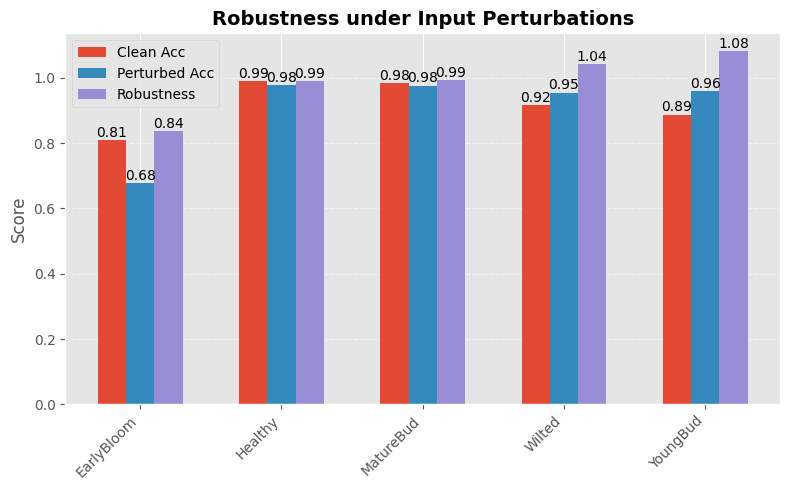

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()

class_names = ['EarlyBloom', 'Healthy', 'MatureBud', 'Wilted', 'YoungBud']
num_classes = len(class_names)

def add_gaussian_noise(img, std=0.1):
    noise = torch.randn_like(img) * std
    return torch.clamp(img + noise, -1, 1)

def change_brightness(img, factor=1.3):
    return torch.clamp(img * factor, -1, 1)

clean_correct = np.zeros(num_classes)
perturbed_correct = np.zeros(num_classes)
total = np.zeros(num_classes)

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        preds_clean = outputs.argmax(1)

        noisy_images = add_gaussian_noise(images, std=0.1)
        bright_images = change_brightness(noisy_images, factor=1.2)

        outputs_pert = model(bright_images)
        if isinstance(outputs_pert, tuple):
            outputs_pert = outputs_pert[0]

        preds_pert = outputs_pert.argmax(1)

        for i in range(len(labels)):
            cls = labels[i].item()

            total[cls] += 1

            if preds_clean[i] == cls:
                clean_correct[cls] += 1

            if preds_pert[i] == cls:
                perturbed_correct[cls] += 1

clean_acc = clean_correct / total
pert_acc = perturbed_correct / total

robustness = np.divide(
    pert_acc,
    clean_acc,
    out=np.zeros_like(pert_acc),
    where=clean_acc != 0
)

print("=== Robustness under Input Perturbations ===\n")

for i in range(num_classes):
    print(f"{class_names[i]}:")
    print(f"  Clean Acc      : {clean_acc[i]:.4f}")
    print(f"  Perturbed Acc  : {pert_acc[i]:.4f}")
    print(f"  Robustness     : {robustness[i]:.4f}\n")

x = np.arange(num_classes)

plt.figure(figsize=(8, 5))

plt.bar(
    x - 0.2,
    clean_acc,
    width=0.2,
    label='Clean Acc'
)

plt.bar(
    x,
    pert_acc,
    width=0.2,
    label='Perturbed Acc'
)

plt.bar(
    x + 0.2,
    robustness,
    width=0.2,
    label='Robustness'
)

plt.xticks(
    x,
    class_names,
    rotation=45,
    ha='right'
)

plt.ylabel("Score")

plt.title(
    "Robustness under Input Perturbations",
    fontsize=14,
    fontweight='bold'
)

plt.legend()

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

for i in range(num_classes):
    plt.text(
        i - 0.2,
        clean_acc[i] + 0.01,
        f"{clean_acc[i]:.2f}",
        ha='center'
    )

    plt.text(
        i,
        pert_acc[i] + 0.01,
        f"{pert_acc[i]:.2f}",
        ha='center'
    )

    plt.text(
        i + 0.2,
        robustness[i] + 0.01,
        f"{robustness[i]:.2f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

In [25]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
import cv2

model.eval()

class_names = ['EarlyBloom', 'Healthy', 'MatureBud', 'Wilted', 'YoungBud']

def gaussian_noise(img, std):
    noise = torch.randn_like(img) * std
    return torch.clamp(img + noise, -1, 1)

def gaussian_blur(img):
    img_np = img.permute(1,2,0).cpu().numpy()
    img_np = cv2.GaussianBlur(img_np, (3,3), 0)
    return torch.from_numpy(img_np).permute(2,0,1).float()

def brightness(img):
    return torch.clamp(img * 1.15, -1, 1)

def contrast(img):
    return torch.clamp((img - img.mean()) * 1.3 + img.mean(), -1, 1)

def jpeg_compress(img):
    img_np = (img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
    _, enc = cv2.imencode('.jpg', img_np, [int(cv2.IMWRITE_JPEG_QUALITY), 40])
    img_np = cv2.imdecode(enc, 1) / 255.0
    return torch.from_numpy(img_np).permute(2,0,1).float()

def random_crop(img):
    _, h, w = img.shape
    crop = img[:, int(0.075*h):int(0.925*h), int(0.075*w):int(0.925*w)]
    return torch.nn.functional.interpolate(
        crop.unsqueeze(0),
        size=(h, w),
        mode='bilinear',
        align_corners=False
    ).squeeze(0)

def evaluate_dataset(transform_fn=None):

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:

            if transform_fn:
                images = torch.stack([transform_fn(img) for img in images])

            images = images.float().to(device)   # 🔥 FIX
            labels = labels.to(device)

            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = outputs.argmax(1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

conditions = {
    "Clean": None,
    "Gaussian noise (std=0.05)": lambda x: gaussian_noise(x, 0.05),
    "Gaussian noise (std=0.10)": lambda x: gaussian_noise(x, 0.10),
    "Gaussian blur (k=3)": gaussian_blur,
    "Brightness (+0.15)": brightness,
    "Contrast (×1.3)": contrast,
    "JPEG compression (Q=40)": jpeg_compress,
    "Random crop (0.85)": random_crop
}

results = {}

for name, fn in conditions.items():
    print(f"Processing: {name}")

    y_true, y_pred = evaluate_dataset(fn)

    f1 = f1_score(y_true, y_pred, average=None)
    results[name] = f1

df = pd.DataFrame(results, index=class_names).T

print("\n=== Per-Class Robustness (F1-score) ===\n")
display(df.round(6))

print("\nFormatted Table:\n")
print(df.round(6).to_string())

Processing: Clean
Processing: Gaussian noise (std=0.05)
Processing: Gaussian noise (std=0.10)
Processing: Gaussian blur (k=3)
Processing: Brightness (+0.15)
Processing: Contrast (×1.3)
Processing: JPEG compression (Q=40)
Processing: Random crop (0.85)

=== Per-Class Robustness (F1-score) ===



,EarlyBloom,Healthy,MatureBud,Wilted,YoungBud
Clean,0.891986,0.898990,0.920755,0.943144,0.933798
Gaussian noise (std=0.05),0.855072,0.883951,0.941634,0.953333,0.959459
Gaussian noise (std=0.10),0.812030,0.875622,0.945312,0.932907,0.962963
Gaussian blur (k=3),0.825279,0.847059,0.878571,0.923611,0.882353
Brightness (+0.15),0.880282,0.896725,0.910448,0.940000,0.926316
Contrast (×1.3),0.876325,0.892231,0.934866,0.936455,0.952055
JPEG compression (Q=40),0.000000,0.678363,0.676471,0.692042,0.789189
Random crop (0.85),0.861210,0.896725,0.896296,0.946667,0.930070



Formatted Table:

                           EarlyBloom   Healthy  MatureBud    Wilted  YoungBud
Clean                        0.891986  0.898990   0.920755  0.943144  0.933798
Gaussian noise (std=0.05)    0.855072  0.883951   0.941634  0.953333  0.959459
Gaussian noise (std=0.10)    0.812030  0.875622   0.945312  0.932907  0.962963
Gaussian blur (k=3)          0.825279  0.847059   0.878571  0.923611  0.882353
Brightness (+0.15)           0.880282  0.896725   0.910448  0.940000  0.926316
Contrast (×1.3)              0.876325  0.892231   0.934866  0.936455  0.952055
JPEG compression (Q=40)      0.000000  0.678363   0.676471  0.692042  0.789189
Random crop (0.85)           0.861210  0.896725   0.896296  0.946667  0.930070


Mean Confidence (Correct): 0.8451
Mean Confidence (Wrong): 0.593
Expected Calibration Error (ECE): 0.094


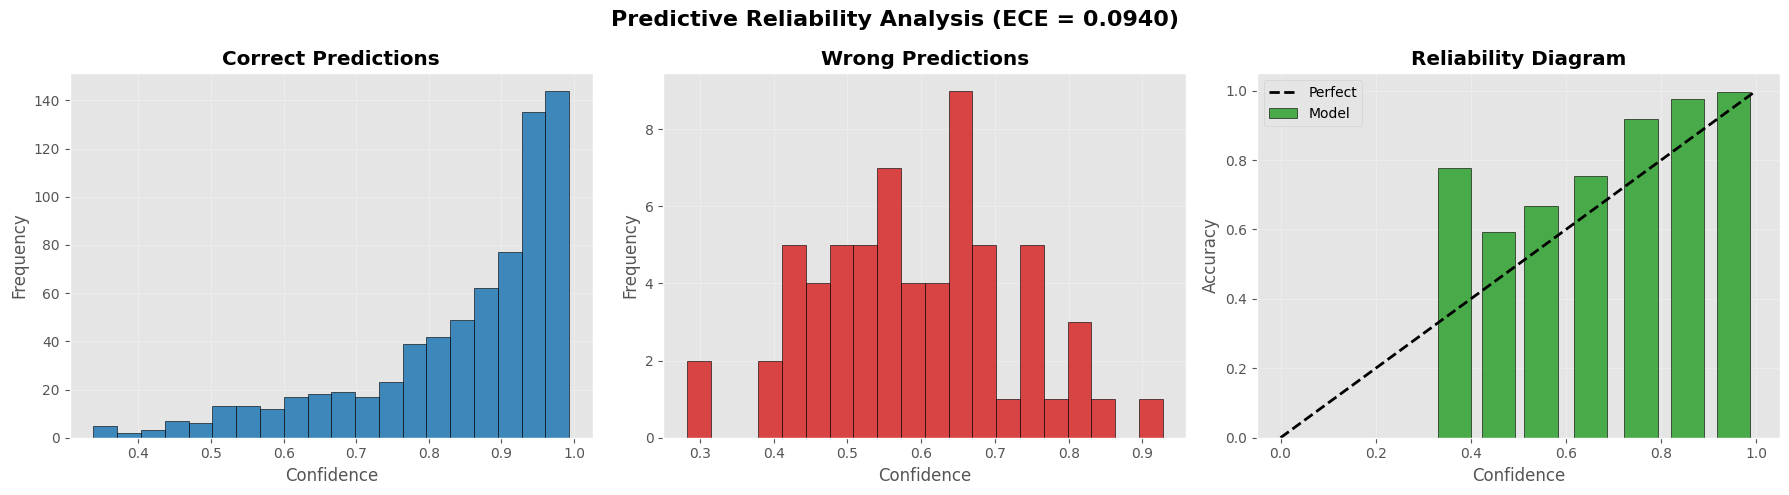


=== Reliability Table ===


,Confidence Bin,Avg Confidence,Accuracy,Samples
0,0.0-0.1,0.050,0.000,0
1,0.1-0.2,0.150,0.000,0
2,0.2-0.3,0.286,0.000,2
3,0.3-0.4,0.366,0.778,9
4,0.4-0.5,0.458,0.593,27
5,0.5-0.6,0.547,0.667,57
6,0.6-0.7,0.651,0.753,73
7,0.7-0.8,0.758,0.920,87
8,0.8-0.9,0.855,0.976,166
9,0.9-1.0,0.952,0.997,346


In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

model.eval()

correct_color = "#1f77b4"  
wrong_color   = "#d62728"   
acc_color     = "#2ca02c"  
perfect_color = "#000000"  

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

confidences = np.max(all_probs, axis=1)
correct = (all_preds == all_labels)

correct_conf = confidences[correct]
wrong_conf = confidences[~correct]

print("Mean Confidence (Correct):", round(np.mean(correct_conf), 4))
print("Mean Confidence (Wrong):", round(np.mean(wrong_conf), 4))

def compute_ece(probs, labels, n_bins=10):

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)

    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0

    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])

        if np.sum(mask) > 0:
            acc = np.mean(predictions[mask] == labels[mask])
            conf = np.mean(confidences[mask])
            ece += np.abs(acc - conf) * np.sum(mask) / len(labels)

    return ece

ece = compute_ece(all_probs, all_labels)
print("Expected Calibration Error (ECE):", round(ece, 4))

def get_reliability_data(probs, labels, n_bins=10):

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)

    bins = np.linspace(0, 1, n_bins+1)

    accs = []
    confs = []
    counts = []

    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])

        if np.sum(mask) > 0:
            acc = np.mean(predictions[mask] == labels[mask])
            conf = np.mean(confidences[mask])
            count = np.sum(mask)
        else:
            acc = 0
            conf = (bins[i]+bins[i+1])/2
            count = 0

        accs.append(acc)
        confs.append(conf)
        counts.append(count)

    return bins, confs, accs, counts


bins, confs, accs, counts = get_reliability_data(all_probs, all_labels)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].hist(
    correct_conf,
    bins=20,
    color=correct_color,
    edgecolor='black',   
    alpha=0.85
)

axes[0].set_title("Correct Predictions", fontweight='bold')
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)

axes[1].hist(
    wrong_conf,
    bins=20,
    color=wrong_color,
    edgecolor='black',  
    alpha=0.85
)

axes[1].set_title("Wrong Predictions", fontweight='bold')
axes[1].set_xlabel("Confidence")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

axes[2].bar(
    confs,
    accs,
    width=0.07,
    color=acc_color,
    edgecolor='black',   
    alpha=0.85,
    label="Model"
)

axes[2].plot(
    [0,1],
    [0,1],
    linestyle='--',
    color=perfect_color,
    linewidth=2,
    label="Perfect"
)

axes[2].set_title("Reliability Diagram", fontweight='bold')
axes[2].set_xlabel("Confidence")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(
    f"Predictive Reliability Analysis (ECE = {ece:.4f})",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

df = pd.DataFrame({
    "Confidence Bin": [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(accs))],
    "Avg Confidence": np.round(confs, 3),
    "Accuracy": np.round(accs, 3),
    "Samples": counts
})

print("\n=== Reliability Table ===")
display(df)


=== Error Analysis Matrix ===


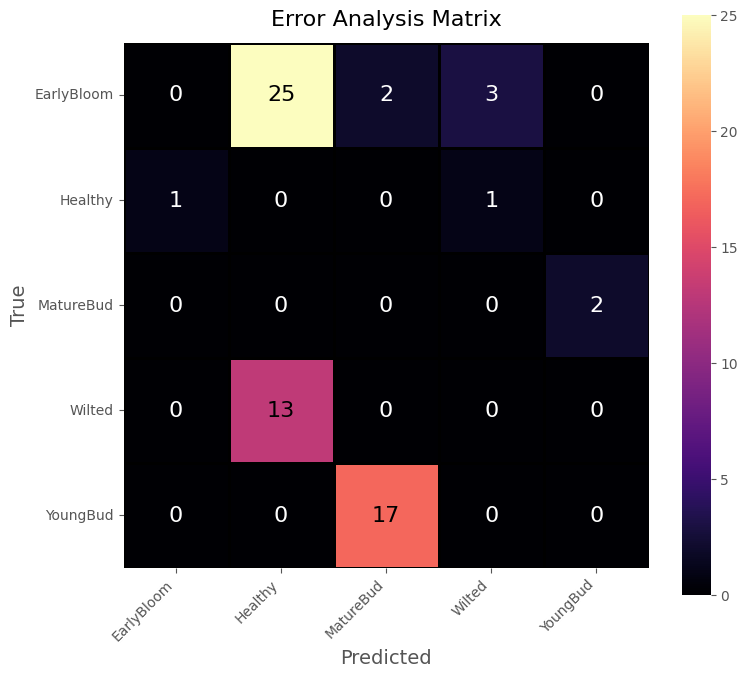

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== Error Analysis Matrix ===")

error_matrix = cm.copy()
np.fill_diagonal(error_matrix, 0)

plt.figure(figsize=(8, 7))

ax = sns.heatmap(
    error_matrix,
    cmap='magma',              
    xticklabels=class_names,
    yticklabels=class_names,
    square=True,
    cbar=True,
    linewidths=0.8,
    linecolor='black',
    annot=False
)

threshold = error_matrix.max() / 2.0

for i in range(error_matrix.shape[0]):
    for j in range(error_matrix.shape[1]):

        val = error_matrix[i, j]

        color = "white" if val < threshold else "black"

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{val}",
            ha="center",
            va="center",
            fontsize=16,        
            color=color
        )

plt.title("Error Analysis Matrix", fontsize=16, pad=12)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

=== Selective Prediction Results ===
 Threshold  Coverage  Accepted Accuracy  Accepted Macro-F1
      0.50  0.950456           0.932785           0.933901
      0.60  0.876141           0.955357           0.955030
      0.70  0.780965           0.979967           0.978383
      0.80  0.667536           0.990234           0.987135
      0.90  0.451108           0.997110           0.987412
      0.95  0.258149           1.000000           1.000000
      0.99  0.007823           1.000000           1.000000


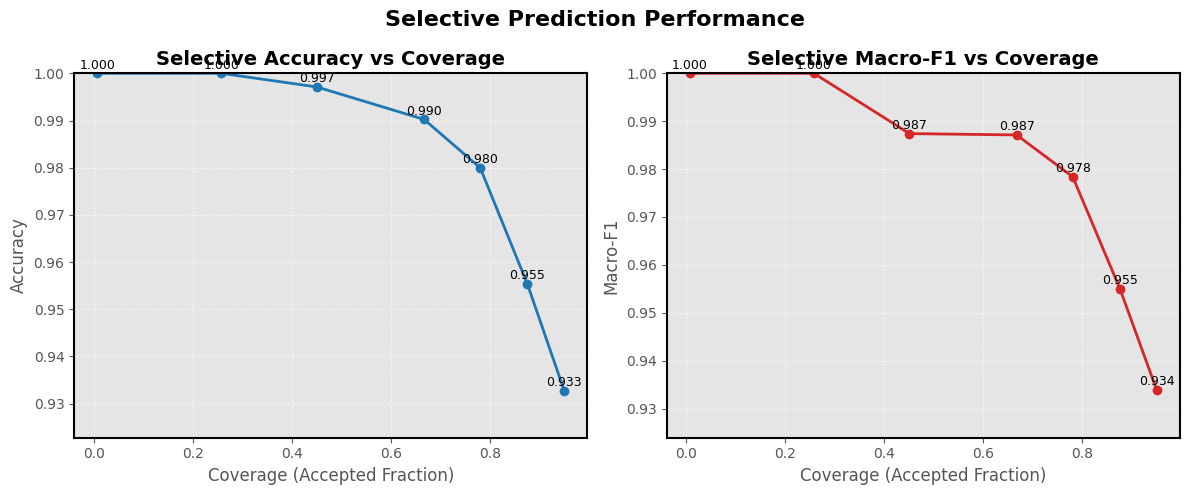

In [33]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

predictions = np.argmax(all_probs, axis=1)
confidences = np.max(all_probs, axis=1)

thresholds = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]

coverage = []
accepted_accuracy = []
accepted_macro_f1 = []

for threshold in thresholds:
    accepted = confidences >= threshold
    n_accepted = accepted.sum()
    cov = n_accepted / len(all_labels)
    coverage.append(cov)

    if n_accepted > 0:
        acc = accuracy_score(
            all_labels[accepted],
            predictions[accepted]
        )
        f1 = f1_score(
            all_labels[accepted],
            predictions[accepted],
            average='macro',
            zero_division=0
        )
    else:
        acc = np.nan
        f1 = np.nan

    accepted_accuracy.append(acc)
    accepted_macro_f1.append(f1)

df = pd.DataFrame({
    "Threshold": thresholds,
    "Coverage": coverage,
    "Accepted Accuracy": accepted_accuracy,
    "Accepted Macro-F1": accepted_macro_f1
})

print("=== Selective Prediction Results ===")
print(df.to_string(index=False))

plt.figure(figsize=(12, 5))

acc_color = "#1f77b4"
f1_color = "#d62728"

ax1 = plt.subplot(1, 2, 1)
plt.plot(
    df["Coverage"],
    df["Accepted Accuracy"],
    marker='o',
    linewidth=2,
    markersize=6,
    color=acc_color
)

for x, y in zip(df["Coverage"], df["Accepted Accuracy"]):
    if not np.isnan(y):
        plt.text(x, y + 0.001, f"{y:.3f}", fontsize=9, ha='center')

plt.xlabel("Coverage (Accepted Fraction)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Selective Accuracy vs Coverage", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(max(0, np.nanmin(df["Accepted Accuracy"]) - 0.01), 1.0)

for spine in ax1.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.5)

ax2 = plt.subplot(1, 2, 2)
plt.plot(
    df["Coverage"],
    df["Accepted Macro-F1"],
    marker='o',
    linewidth=2,
    markersize=6,
    color=f1_color
)

for x, y in zip(df["Coverage"], df["Accepted Macro-F1"]):
    if not np.isnan(y):
        plt.text(x, y + 0.001, f"{y:.3f}", fontsize=9, ha='center')

plt.xlabel("Coverage (Accepted Fraction)", fontsize=12)
plt.ylabel("Macro-F1", fontsize=12)
plt.title("Selective Macro-F1 vs Coverage", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(max(0, np.nanmin(df["Accepted Macro-F1"]) - 0.01), 1.0)

for spine in ax2.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.5)

plt.suptitle(
    "Selective Prediction Performance",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader

device_cpu = torch.device("cpu")
model = model.to(device_cpu)

batch_size = 8
test_loader_small = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]

def fgsm_attack(images, epsilon, grad):
    return torch.clamp(images + epsilon * grad.sign(), -1, 1)

results = []

model.eval()

for eps in epsilons:

    all_preds = []
    all_labels = []

    for images, labels in test_loader_small:

        images = images.to(device_cpu)
        labels = labels.to(device_cpu)

        images.requires_grad = True

        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        loss = loss_fn(outputs, labels)

        model.zero_grad()
        loss.backward()

        grad = images.grad.detach()

        perturbed_images = fgsm_attack(images.detach(), eps, grad)

        with torch.no_grad():
            outputs = model(perturbed_images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = outputs.argmax(1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

        del images, grad, perturbed_images, outputs

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    results.append([eps, acc, f1])

df_fgsm = pd.DataFrame(results, columns=["Epsilon", "Accuracy", "Macro-F1"])

print("\n=== FGSM Attack Results ===")
display(df_fgsm.round(4))

plt.figure(figsize=(8,5))

plt.plot(
    df_fgsm["Epsilon"],
    df_fgsm["Accuracy"],
    marker='o',
    color='#e74c3c',
    linewidth=2.5,
    markersize=7,
    label='Accuracy'
)

plt.plot(
    df_fgsm["Epsilon"],
    df_fgsm["Macro-F1"],
    marker='s',
    linestyle='--',
    color='#3498db',
    linewidth=2.5,
    markersize=7,
    label='Macro-F1'
)

plt.scatter(
    df_fgsm["Epsilon"][0],
    df_fgsm["Accuracy"][0],
    color='black',
    s=100,
    zorder=5,
    label='Clean'
)

for x, y in zip(df_fgsm["Epsilon"], df_fgsm["Accuracy"]):
    plt.text(x, y+0.005, f"{y:.2f}", fontsize=9, ha='center')

plt.xlabel("Epsilon (Attack Strength)", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.title(
    "Impact of FGSM Attack on Model Performance",
    fontsize=14,
    fontweight='bold'
)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

ax = plt.gca()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()